# 16 — Refined Goodreads quality vs reach

**Secondary / discriminant + exploratory analysis.** This notebook does **not** alter
Notebook 13 H1–H6 confirmatory verdicts, does not redefine frozen Stage 11 constructs,
and does not edit Stage 10 Notebook 06 (taxonomy-era baseline).

## Central question

Do narrative features associated with **reader appreciation** differ from those associated
with **reach / popularity**, once Stage 10 taxonomy leaves are replaced by semantically
refined Stage 11 constructs?

Internally we retain:

- `rating_shrunk` — primary reader-appreciation channel (reliability-weighted)
- `avg_rating` — raw-rating sensitivity
- `log_n_ratings` — reach / popularity channel

Neither channel is an absolute measure of literary quality or commercial success.
Reach is a popularity/exposure proxy influenced by publication history, distribution,
series effects, marketing and platform dynamics; it is not a direct reader-preference measure.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats as sps

cwd = Path.cwd().resolve()
root = cwd
for _ in range(6):
    if (root / "configs").is_dir() and (root / "src").is_dir():
        break
    root = root.parent
else:
    raise RuntimeError("Could not find project root")
if str(root) not in sys.path:
    sys.path.insert(0, str(root))

from src.stage10_correlation_analysis.analysis import effects as eff
from src.stage10_correlation_analysis.analysis import models as mdl
from src.stage11_refined_construct_analysis.analysis import exploratory_ees as ees
from src.stage11_refined_construct_analysis.analysis import exploratory_security as ex
from src.stage11_refined_construct_analysis.analysis import notebook_helpers as nh
from src.stage11_refined_construct_analysis.analysis import presentation as pres
from src.stage11_refined_construct_analysis.analysis import thematic_richness as tr

ctx = nh.setup("16_refined_goodreads_quality_reach")
cfg = ctx.cfg
GATE = nh.effect_gate(cfg)
ALPHA = 0.05
SEED = 42
N_BOOT = 400
MIN_RATINGS = 30

QUALITY = "rating_shrunk"
QUALITY_RAW = "avg_rating"
REACH = "log_n_ratings"
WEIGHT = "reliability"
NUMERIC_CONTROLS = ["log_pages", "n_sentences", "publication_year"]
CATEGORICAL = ["genre_group"]
CLUSTER = "author_id"
TIER_COL = "rating_class"
HIGH, LOW = "high_rate", "low_rate"

coverage = nh.load_construct_coverage(cfg)

Project root : /home/polina/Documents/Cursor_Projects/romantic_novels_large_corpus
Config       : configs/stage11/refined_constructs.yaml
Run          : v4_l12_granular_final_call49
Outputs      : results/stage11_refined_construct_analysis/v4_l12_granular_final_call49/notebook_analysis/16_refined_goodreads_quality_reach


In [2]:
frame = nh.load_refined_frame(cfg, "strict")
if "book_id" in frame.columns:
    frame = frame.set_index("book_id")
usable = frame[frame["analysable"].fillna(True)].copy() if "analysable" in frame.columns else frame.copy()
work = usable.reset_index()
if "n_ratings" not in work.columns and REACH in work.columns:
    work["n_ratings"] = np.expm1(work[REACH].astype(float)).clip(lower=0)
work = pres.add_year_bin(work)
work = pres.residualize_outcomes(work)
work = pres.residual_goodreads_quadrants(work)

n_books = len(work)
n_authors = work["author_id"].nunique() if "author_id" in work.columns else float("nan")
print(f"{n_books:,} analysable books, {n_authors:,.0f} authors")
print(f"Appreciation: {QUALITY} (weighted by {WEIGHT}) | Reach: {REACH}")
assert n_books > 10_000, "Unexpectedly small analysable corpus"

15,999 analysable books, 8,263 authors
Appreciation: rating_shrunk (weighted by reliability) | Reach: log_n_ratings


## 0. Scope and claim boundary

- Notebook 13 remains the confirmatory source of truth for H1–H6.
- Reach findings never upgrade confirmatory support.
- `unmeasurable` constructs stay unmeasurable (NaN), never zero.
- Thin constructs stay visibly labelled.

In [3]:
print(
    "Claim boundary locked: secondary discriminant analysis only. "
    "No H1–H6 verdict changes; no construct redefinition."
)

Claim boundary locked: secondary discriminant analysis only. No H1–H6 verdict changes; no construct redefinition.


## 1. Reader appreciation and reach are different channels

Before refined constructs: reproduce Stage 10 channel calibration
(correlations, shrinkage warning, controls-only models).

In [4]:
pair = work[[QUALITY, QUALITY_RAW, REACH, "n_ratings"]].dropna()
correlations = pd.DataFrame(
    [
        {
            "pair": "shrunk rating vs log ratings count",
            "pearson_r": sps.pearsonr(pair[QUALITY], pair[REACH])[0],
            "spearman_rho": sps.spearmanr(pair[QUALITY], pair[REACH])[0],
        },
        {
            "pair": "raw rating vs log ratings count",
            "pearson_r": sps.pearsonr(pair[QUALITY_RAW], pair[REACH])[0],
            "spearman_rho": sps.spearmanr(pair[QUALITY_RAW], pair[REACH])[0],
        },
        {
            "pair": "raw rating vs shrunk rating",
            "pearson_r": sps.pearsonr(pair[QUALITY_RAW], pair[QUALITY])[0],
            "spearman_rho": sps.spearmanr(pair[QUALITY_RAW], pair[QUALITY])[0],
        },
    ]
)
display(correlations.round(4))
ctx.save_table(correlations, "channel_correlations")

shrunk_r = float(correlations.iloc[0]["pearson_r"])
raw_r = float(correlations.iloc[1]["pearson_r"])
print(
    f"\nShrunk appreciation and reach share {shrunk_r ** 2 * 100:.1f}% of variance; "
    f"raw rating and reach share {raw_r ** 2 * 100:.1f}%."
)
print(
    "\nShrinkage warning: `rating_shrunk` partly depends on the amount of rating "
    "information, so its correlation with `log_n_ratings` is partly mechanically induced. "
    "Shrunk weighted rating = primary reader-appreciation model; raw rating = mandatory "
    "sensitivity check."
)

,pair,pearson_r,spearman_rho
0,shrunk rating vs log ratings count,0.2062,0.1561
1,raw rating vs log ratings count,0.1241,0.0971
2,raw rating vs shrunk rating,0.7578,0.8968


  saved table: results/stage11_refined_construct_analysis/v4_l12_granular_final_call49/notebook_analysis/16_refined_goodreads_quality_reach/tables/channel_correlations.csv  (3 rows)

Shrunk appreciation and reach share 4.3% of variance; raw rating and reach share 1.5%.

Shrinkage warning: `rating_shrunk` partly depends on the amount of rating information, so its correlation with `log_n_ratings` is partly mechanically induced. Shrunk weighted rating = primary reader-appreciation model; raw rating = mandatory sensitivity check.


  saved figure: results/stage11_refined_construct_analysis/v4_l12_granular_final_call49/notebook_analysis/16_refined_goodreads_quality_reach/figures/01_two_channels_overview.png


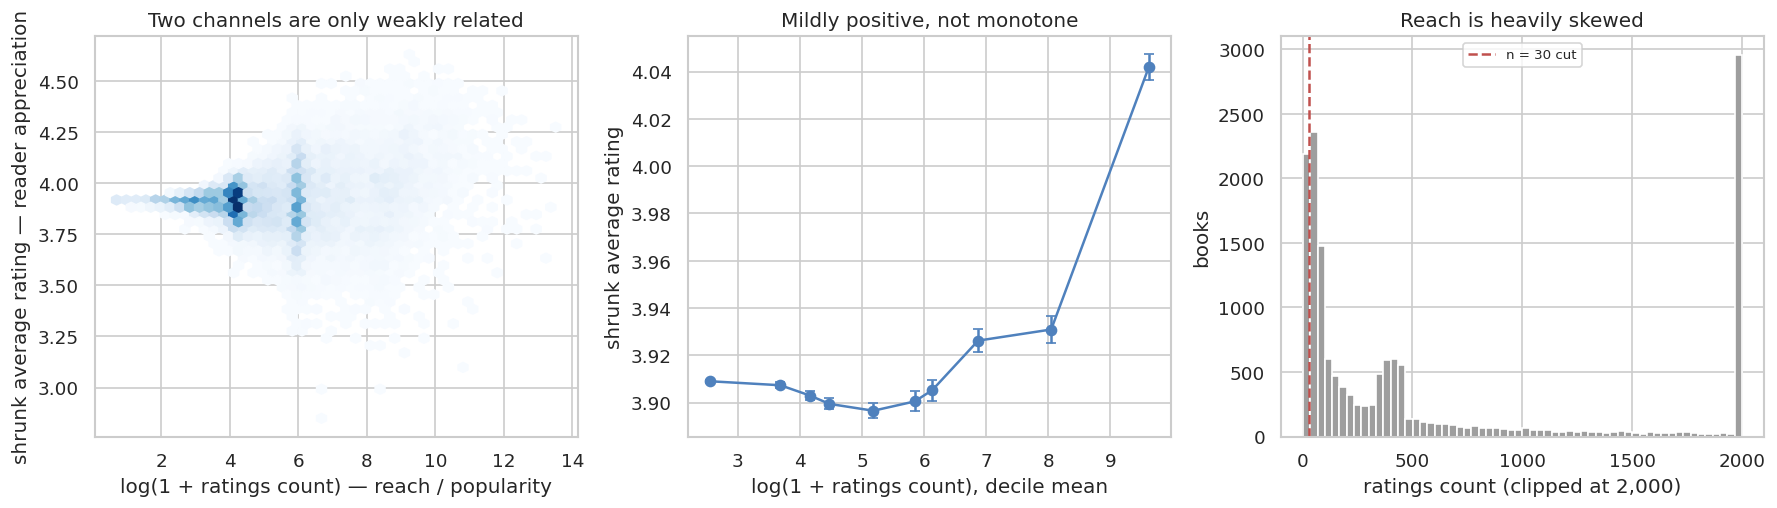

In [5]:
fig, axes_row = plt.subplots(1, 3, figsize=(15, 4.4))
axes_row[0].hexbin(pair[REACH], pair[QUALITY], gridsize=45, cmap="Blues", mincnt=1)
axes_row[0].set_xlabel("log(1 + ratings count) — reach / popularity")
axes_row[0].set_ylabel("shrunk average rating — reader appreciation")
axes_row[0].set_title("Two channels are only weakly related")

deciles = pair.copy()
deciles["reach_decile"] = pd.qcut(deciles[REACH], 10, labels=False, duplicates="drop")
profile = (
    deciles.groupby("reach_decile")
    .agg(
        reach=(REACH, "mean"),
        rating=(QUALITY, "mean"),
        sem=(QUALITY, lambda s: s.std() / np.sqrt(len(s))),
        n=(QUALITY, "size"),
    )
    .reset_index()
)
axes_row[1].errorbar(
    profile["reach"], profile["rating"], yerr=profile["sem"], marker="o", color="#4f81bd", capsize=3
)
axes_row[1].set_xlabel("log(1 + ratings count), decile mean")
axes_row[1].set_ylabel("shrunk average rating")
axes_row[1].set_title("Mildly positive, not monotone")

axes_row[2].hist(pair["n_ratings"].clip(upper=2000), bins=60, color="#9e9e9e")
axes_row[2].axvline(MIN_RATINGS, color="#c0504d", ls="--", label=f"n = {MIN_RATINGS} cut")
axes_row[2].set_xlabel("ratings count (clipped at 2,000)")
axes_row[2].set_ylabel("books")
axes_row[2].set_title("Reach is heavily skewed")
axes_row[2].legend(fontsize=8)
fig.tight_layout()
ctx.save_figure(fig, "01_two_channels_overview")
plt.show()

In [6]:
control_fits = [
    mdl.fit_ols(
        work,
        QUALITY,
        [c for c in NUMERIC_CONTROLS if c in work.columns],
        categorical=[c for c in CATEGORICAL if c in work.columns],
        cluster=CLUSTER if CLUSTER in work.columns else None,
        weights=WEIGHT if WEIGHT in work.columns else None,
        name="appreciation ~ controls",
    ),
    mdl.fit_ols(
        work,
        REACH,
        [c for c in NUMERIC_CONTROLS if c in work.columns],
        categorical=[c for c in CATEGORICAL if c in work.columns],
        cluster=CLUSTER if CLUSTER in work.columns else None,
        name="reach ~ controls",
    ),
]
baseline = pd.DataFrame(
    [
        {
            "channel": f.name,
            "n_obs": f.n_obs,
            "n_clusters": f.n_clusters,
            "r_squared": f.r_squared,
            "adj_r_squared": f.extra.get("adj_r_squared"),
            "weighted": f.extra.get("weighted"),
        }
        for f in control_fits
    ]
)
coef_rows = []
for f in control_fits:
    part = f.coefficients.copy()
    part["channel"] = f.name
    coef_rows.append(part)
controls_coef = pd.concat(coef_rows, ignore_index=True)
display(baseline.round(4))
display(controls_coef.round(4).head(40))
ctx.save_table(baseline, "controls_only_baselines")
ctx.save_table(controls_coef, "controls_only_coefficients")
print(
    "\nReach is particularly sensitive to exposure/background variables "
    "(publication year, length, genre). It is a popularity/exposure proxy — "
    "not a direct reader-preference measure."
)

,channel,n_obs,n_clusters,r_squared,adj_r_squared,weighted
0,appreciation ~ controls,15999,8263,0.1118,0.1114,True
1,reach ~ controls,15999,8263,0.1247,0.1244,False


,term,coefficient,std_error,t_statistic,p_value,ci_low,ci_high,channel
0,const,-18.1324,1.9820,-9.1483,0.0000,-22.0171,-14.2476,appreciation ~ controls
1,log_pages,0.0862,0.0076,11.3062,0.0000,0.0713,0.1012,appreciation ~ controls
2,n_sentences,0.0000,0.0000,7.3589,0.0000,0.0000,0.0000,appreciation ~ controls
3,publication_year,0.0107,0.0010,10.8207,0.0000,0.0088,0.0126,appreciation ~ controls
4,genre_group_mystery,0.0653,0.0102,6.4144,0.0000,0.0453,0.0852,appreciation ~ controls
5,genre_group_other,0.0208,0.0086,2.4173,0.0156,0.0039,0.0376,appreciation ~ controls
6,genre_group_paranormal,0.0510,0.0106,4.8097,0.0000,0.0302,0.0718,appreciation ~ controls
7,genre_group_young_adult,-0.0009,0.0115,-0.0776,0.9382,-0.0234,0.0216,appreciation ~ controls
8,const,196.7778,17.6414,11.1543,0.0000,162.2013,231.3542,reach ~ controls
9,log_pages,1.0929,0.0684,15.9831,0.0000,0.9589,1.2270,reach ~ controls


  saved table: results/stage11_refined_construct_analysis/v4_l12_granular_final_call49/notebook_analysis/16_refined_goodreads_quality_reach/tables/controls_only_baselines.csv  (2 rows)
  saved table: results/stage11_refined_construct_analysis/v4_l12_granular_final_call49/notebook_analysis/16_refined_goodreads_quality_reach/tables/controls_only_coefficients.csv  (16 rows)

Reach is particularly sensitive to exposure/background variables (publication year, length, genre). It is a popularity/exposure proxy — not a direct reader-preference measure.


## 2. From taxonomy leaves to refined narrative functions

Stage 10 found largely separate appreciation and reach channels, but several taxonomy
leaves mixed distinct narrative functions (care vs protection, appearance vs grooming,
danger vs enacted protection). Notebook 16 asks which quality/reach distinctions
survive semantic refinement, which disappear, and which become more specific.

In [7]:
print(
    "Stage 11 replaces mixed taxonomy leaves with function-specific constructs "
    "from Notebooks 12–15. The channel contrast is re-estimated on those constructs."
)

Stage 11 replaces mixed taxonomy leaves with function-specific constructs from Notebooks 12–15. The channel contrast is re-estimated on those constructs.


## 3. Feature registry and measurement status

One registry drives every table and figure. Confirmatory, qualified, thin, and
exploratory features remain visibly distinct.

In [8]:
shares = ex.topic_share_matrix(cfg)
exp_cfg = ex.load_exploratory_config(
    root / "configs/stage11/exploratory_security_care_appearance.yaml"
)
ees_cfg = ees.load_exploratory_ees_config(
    root / "configs/stage11/exploratory_emotion_embodiment_social_world.yaml"
)
families = exp_cfg.get("families") or {}
frac_cfg = exp_cfg.get("fractional_protection") or {}
frac_topics = [int(t) for t in (frac_cfg.get("candidate_topics") or [])]
frac_weights = ex.build_fractional_protection_weights(
    cfg,
    candidate_topics=frac_topics,
    protection_codes=frac_cfg.get("protection_codes"),
)
work = ex.add_topic_set_columns(work, shares, families, fractional_weights=frac_weights)
work = ees.add_ees_share_columns(work, shares, ees_cfg, level="moderate")
domains = ees_cfg.get("social_domains") or {}
if domains:
    work["EES_social_domain_richness"] = ees.social_domain_richness(work, shares, domains)

# Work / cognition screen columns (exploratory; no new coding)
work_codes = (ees_cfg.get("code_membership") or {}).get("work") or {}
for code, tids in work_codes.items():
    col = f"EES_work_{code}"
    work[col] = ex._align_series_to_frame(
        ex.topic_set_share(shares, [int(t) for t in (tids or [])]), work
    ).values

cog_codes = (ees_cfg.get("code_membership") or {}).get("cognition") or {}
for code, tids in cog_codes.items():
    col = f"EES_cog_{code}"
    work[col] = ex._align_series_to_frame(
        ex.topic_set_share(shares, [int(t) for t in (tids or [])]), work
    ).values

work, richness_meta = tr.compute_all_richness(cfg, work, seed=SEED, length_quantile=0.10)
print("Richness meta:", richness_meta)

# --- Registry construction ---
PRIMARY = [
    ("H1", "RLR_emotional_vs_explicit", "Emotional vs explicit ratio", "intimacy"),
    ("H2", "RAX_h2_strict", "Strict final payoff", "payoff"),
    ("H3", "RLR_emotional_vs_material_security", "Emotional vs material security", "security"),
    ("H4", "RLR_protection_vs_control", "Protection vs possession", "protection"),
    ("H5", "RLR_darkness_vs_tenderness", "Darkness vs tenderness", "darkness_tenderness"),
    ("H6", "RARC", "Refined arc contrast", "arc"),
]
COMPONENTS = [
    ("H1", "RAX_emotional_reassurance", "Emotional reassurance", "security"),
    ("H1", "RAX_explicit_sex", "Explicit sex", "intimacy"),
    ("H1", "RAX_nonexplicit_affection", "Non-explicit affection", "intimacy"),
    ("H3", "RAX_h3_emotional_side", "Emotional security / reassurance", "security"),
    ("H3", "RAX_h3_material_side", "Material provision side", "security"),
    ("H3", "RAX_appearance_grooming", "Grooming / self-presentation", "appearance"),
    ("H4", "RAX_external_protection", "Enacted protection", "protection"),
    ("H4", "RAX_protective_commitment", "Protective commitment", "protection"),
    ("H4", "RAX_h4_possession_side", "Possession / control", "protection"),
    ("H5", "RAX_tenderness_core", "Tenderness", "darkness_tenderness"),
    ("H5", "RAX_external_danger_crisis", "External danger", "danger"),
    ("H5", "RAX_individual_distress", "Individual distress", "emotion"),
    ("H5", "RAX_relational_darkness", "Relational darkness", "darkness_tenderness"),
    ("H6", "DELTA_rising", "Rising Δ (end−begin)", "arc"),
    ("H6", "DELTA_falling", "Falling Δ (end−begin)", "arc"),
]

# Evidence-tier hints from NB13 claim hierarchy
TIER_OVERRIDE = {
    "RAX_h3_emotional_side": "frozen_reportable",
    "RAX_appearance_grooming": "frozen_reportable",
    "RAX_emotional_reassurance": "frozen_reportable",
    "RAX_external_danger_crisis": "qualified",
    "RAX_external_protection": "thin",
    "RAX_protective_commitment": "frozen_reportable",  # often unmeasurable under strict
    "RLR_protection_vs_control": "thin",
    "RLR_emotional_vs_material_security": "frozen_reportable",
    "RAX_h2_strict": "frozen_reportable",
    "RAX_h3_material_side": "frozen_reportable",
}

reg_rows = []
for hyp, feat, label, family in PRIMARY + COMPONENTS:
    gate = nh.gate_for_feature(coverage, feat)
    tier = TIER_OVERRIDE.get(feat, "frozen_reportable")
    if gate == "thin" and tier == "frozen_reportable":
        tier = "thin"
    if gate == "unmeasurable":
        tier = "frozen_reportable"  # still confirmatory slot, but unmeasurable
    preferred = gate != "unmeasurable" and feat not in {
        "RAX_h2_strict",
        "RLR_emotional_vs_material_security",
        "RAX_h3_material_side",
        "RAX_protective_commitment",
        "DELTA_rising",
        "DELTA_falling",
        "RARC",
        "RLR_emotional_vs_explicit",
        "RLR_darkness_vs_tenderness",
        "RLR_protection_vs_control",
    }
    # Prefer human-readable components on main plot; keep selected primaries off clutter
    if feat in {
        "RAX_emotional_reassurance",
        "RAX_explicit_sex",
        "RAX_nonexplicit_affection",
        "RAX_h3_emotional_side",
        "RAX_appearance_grooming",
        "RAX_external_protection",
        "RAX_h4_possession_side",
        "RAX_tenderness_core",
        "RAX_external_danger_crisis",
        "RAX_individual_distress",
        "RAX_relational_darkness",
    }:
        preferred = gate != "unmeasurable"
    notes = []
    if gate == "thin":
        notes.append("thin")
    if gate == "unmeasurable":
        notes.append("unmeasurable under strict freeze")
    if feat == "RAX_external_protection":
        notes.append("thin / one clean topic")
    if feat == "RLR_protection_vs_control":
        notes.append("thin/provisional H4 ratio")
    reg_rows.append(
        {
            "feature": feat,
            "display_label": label,
            "family": family,
            "source_notebook": "13",
            "evidence_tier": tier,
            "measurement_gate": gate,
            "preferred_for_main_plot": preferred,
            "exploratory": False,
            "notes": "; ".join(notes),
            "hypothesis": hyp,
        }
    )

# NB12 security families — all breadths in sensitivity; preferred strict when measurable
FAMILY_LABELS = {
    "emotional_security": "Emotional security (exploratory)",
    "protective_commitment": "Protective commitment (exploratory)",
    "enacted_protection": "Enacted protection (exploratory)",
    "practical_care": "Practical care",
    "material_security": "Material security (exploratory)",
    "appearance": "Appearance (exploratory family)",
    "possessive_security": "Possessive security",
}
for fam, levels in families.items():
    if not isinstance(levels, dict):
        continue
    for level in ("strict", "moderate", "broad"):
        tids = levels.get(level) or []
        feat = f"EXP_{fam}_{level}"
        n_topics = len(tids)
        if n_topics == 0:
            gate = "unmeasurable"
        elif n_topics <= 2:
            gate = "thin"
        else:
            gate = "viable"
        if level == "strict" and gate != "unmeasurable":
            tier = "thin" if gate == "thin" else "exploratory"
            preferred = True
            if fam == "enacted_protection":
                notes = "thin / one clean topic" if gate == "thin" else ""
            else:
                notes = ""
        elif level == "moderate" and gate != "unmeasurable":
            # Prefer moderate only when strict is empty (no silent substitution on main plot)
            strict_n = len(levels.get("strict") or [])
            tier = "exploratory_moderate"
            preferred = False
            notes = "exploratory moderate; strict unmeasurable" if strict_n == 0 else "breadth sensitivity"
        else:
            tier = "exploratory"
            preferred = False
            notes = "breadth sensitivity"
        # Exclude highly selected protective-commitment promise bundles from principal ranking
        if fam == "protective_commitment":
            preferred = False
            notes = (notes + "; excluded from principal ranking").strip("; ")
        reg_rows.append(
            {
                "feature": feat,
                "display_label": f"{FAMILY_LABELS.get(fam, fam)} [{level}]",
                "family": fam,
                "source_notebook": "12",
                "evidence_tier": tier,
                "measurement_gate": gate,
                "preferred_for_main_plot": preferred and gate != "unmeasurable",
                "exploratory": True,
                "notes": notes,
                "hypothesis": "EXP",
            }
        )

# NB15 EES broad constructs
EES_SPECS = [
    ("EES_emotion_distress_expressed", "Expressed distress", "emotion"),
    ("EES_emotion_physiological_arousal", "Physiological emotion", "emotion"),
    ("EES_emotion_physical_vulnerability", "Physical vulnerability (emotion)", "emotion"),
    ("EES_emotion_visible_affect", "Visible affect", "emotion"),
    ("EES_emotion_containment", "Emotion containment", "emotion"),
    ("EES_emotion_coregulation", "Interpersonal co-regulation", "emotion"),
    ("EES_emotion_physical_comfort", "Physical comfort", "emotion"),
    ("EES_emotion_relief", "Relief", "emotion"),
    ("EES_emotion_rumination", "Rumination", "emotion"),
    ("EES_body_interoceptive", "Interoceptive body", "embodiment"),
    ("EES_body_vulnerable", "Vulnerable body", "embodiment"),
    ("EES_body_markings", "Body markings", "embodiment"),
    ("EES_body_external_appearance", "External appearance", "embodiment"),
    ("EES_body_grooming", "Body grooming", "embodiment"),
    ("EES_felt_body", "Felt body", "embodiment"),
    ("EES_looked_at_body", "Looked-at body", "embodiment"),
    ("EES_felt_vs_looked_logratio", "Felt vs looked-at body", "embodiment"),
    ("EES_family_presence", "Family presence", "social"),
    ("EES_supportive_social_embeddedness", "Supportive social world", "social"),
    ("EES_social_pressure_conflict", "Social pressure / conflict", "social"),
    ("EES_social_domain_richness", "Social-domain richness", "social"),
]
for feat, label, family in EES_SPECS:
    # Gate from topic count when available via YAML families / composites
    fam_key = feat.replace("EES_", "")
    fam_levels = (ees_cfg.get("families") or {}).get(fam_key)
    if isinstance(fam_levels, dict):
        n_topics = len(fam_levels.get("moderate") or fam_levels.get("strict") or [])
    else:
        composites = ees_cfg.get("composites") or {}
        if fam_key in composites:
            n_topics = len(ees.composite_topic_ids(ees_cfg, fam_key, level="moderate"))
        elif feat == "EES_social_domain_richness":
            n_topics = 3
        elif feat == "EES_felt_vs_looked_logratio":
            n_topics = 3
        else:
            n_topics = 3 if feat in work.columns else 0
    if n_topics == 0:
        gate = "unmeasurable"
    elif n_topics <= 2:
        gate = "thin"
    else:
        gate = "viable"
    preferred = gate != "unmeasurable" and family in {"emotion", "embodiment", "social"}
    # Keep distress on registry but it often nulls — still preferred for null reporting
    reg_rows.append(
        {
            "feature": feat,
            "display_label": label,
            "family": family,
            "source_notebook": "15",
            "evidence_tier": "exploratory",
            "measurement_gate": gate,
            "preferred_for_main_plot": preferred,
            "exploratory": True,
            "notes": "",
            "hypothesis": "EES",
        }
    )

WORK_LABELS = {
    "transactional_business": "Transactional business talk",
    "occupational_competence": "Occupational competence",
    "shared_work": "Shared work",
    "institutional_setting": "Institutional setting",
    "hierarchy_power": "Hierarchy / power",
    "economic_pressure": "Economic pressure",
    "status_wealth": "Status / wealth",
    "generic_logistics": "Generic logistics",
}
for code, tids in work_codes.items():
    feat = f"EES_work_{code}"
    n_topics = len(tids or [])
    gate = "unmeasurable" if n_topics == 0 else ("thin" if n_topics <= 2 else "viable")
    reg_rows.append(
        {
            "feature": feat,
            "display_label": WORK_LABELS.get(code, code.replace("_", " ").title()),
            "family": "work",
            "source_notebook": "15",
            "evidence_tier": "exploratory_screen",
            "measurement_gate": gate,
            "preferred_for_main_plot": False,  # secondary panel only
            "exploratory": True,
            "notes": "exploratory screen",
            "hypothesis": "EES_work",
        }
    )

for code, tids in cog_codes.items():
    feat = f"EES_cog_{code}"
    n_topics = len(tids or [])
    gate = "unmeasurable" if n_topics == 0 else ("thin" if n_topics <= 2 else "viable")
    reg_rows.append(
        {
            "feature": feat,
            "display_label": f"Cognition: {code.replace('_', ' ')}",
            "family": "cognition",
            "source_notebook": "15",
            "evidence_tier": "exploratory_screen",
            "measurement_gate": gate,
            "preferred_for_main_plot": False,
            "exploratory": True,
            "notes": "screen-level; not on main figure",
            "hypothesis": "EES_cog",
        }
    )

RICHNESS_SPECS = [
    ("topic_n_eff", "Topic richness (n_eff)", "richness"),
    ("taxonomy_n_eff", "Taxonomy richness (n_eff)", "richness"),
    ("rare_topic_n_eff", "Rarefied topic richness", "richness"),
    ("rare_taxonomy_n_eff", "Rarefied taxonomy richness", "richness"),
    ("taxonomy_top10", "Taxonomy top-10 concentration", "richness"),
]
for feat, label, family in RICHNESS_SPECS:
    present = feat in work.columns
    reg_rows.append(
        {
            "feature": feat,
            "display_label": label,
            "family": family,
            "source_notebook": "14",
            "evidence_tier": "exploratory",
            "measurement_gate": "viable" if present else "unmeasurable",
            "preferred_for_main_plot": False,
            "exploratory": True,
            "notes": "length-sensitive; prefer controlled/rarefied reading",
            "hypothesis": "RICH",
        }
    )

registry = pd.DataFrame(reg_rows).drop_duplicates(subset=["feature"], keep="first")
# Drop features absent from frame (except keep unmeasurable NB13 rows for transparency)
registry["in_frame"] = registry["feature"].isin(work.columns)
registry.loc[
    ~registry["in_frame"] & (registry["measurement_gate"] != "unmeasurable"),
    "measurement_gate",
] = "unmeasurable"
display(registry[["feature", "display_label", "family", "source_notebook", "evidence_tier", "measurement_gate", "preferred_for_main_plot"]].head(40))
ctx.save_table(registry, "refined_feature_registry")
label_map = registry.set_index("feature")["display_label"].to_dict()
print(
    f"Registry: {len(registry)} features; "
    f"{int(registry['preferred_for_main_plot'].sum())} preferred for main plot; "
    f"{int((registry['measurement_gate'] == 'unmeasurable').sum())} unmeasurable."
)

Richness meta: {'rarefaction_depth': 3098, 'n_rarefaction_eligible': 14364, 'n_topics': 373, 'n_leaves': 45, 'n_constructs': 10, 'length_quantile': 0.1, 'seed': 42}


,feature,display_label,family,source_notebook,evidence_tier,measurement_gate,preferred_for_main_plot
0,RLR_emotional_vs_explicit,Emotional vs explicit ratio,intimacy,13,frozen_reportable,viable,False
1,RAX_h2_strict,Strict final payoff,payoff,13,frozen_reportable,unmeasurable,False
2,RLR_emotional_vs_material_security,Emotional vs material security,security,13,frozen_reportable,unmeasurable,False
3,RLR_protection_vs_control,Protection vs possession,protection,13,thin,thin,False
4,RLR_darkness_vs_tenderness,Darkness vs tenderness,darkness_tenderness,13,frozen_reportable,viable,False
5,RARC,Refined arc contrast,arc,13,frozen_reportable,viable,False
6,RAX_emotional_reassurance,Emotional reassurance,security,13,frozen_reportable,viable,True
7,RAX_explicit_sex,Explicit sex,intimacy,13,frozen_reportable,viable,True
8,RAX_nonexplicit_affection,Non-explicit affection,intimacy,13,frozen_reportable,viable,True
9,RAX_h3_emotional_side,Emotional security / reassurance,security,13,frozen_reportable,viable,True


  saved table: results/stage11_refined_construct_analysis/v4_l12_granular_final_call49/notebook_analysis/16_refined_goodreads_quality_reach/tables/refined_feature_registry.csv  (82 rows)
Registry: 82 features; 37 preferred for main plot; 6 unmeasurable.


## 4. All refined constructs against both channels

Standardised partial betas: appreciation WLS with reliability weights; reach OLS
unweighted; author-clustered SE. BH-FDR is descriptive screening within each channel
(does not touch Notebook 13 FDR). Cliff's-δ gate of 0.11 is **not** applied to betas.

In [9]:
measurable = registry[
    (registry["measurement_gate"] != "unmeasurable") & registry["in_frame"]
].copy()
feat_list = [f for f in measurable["feature"] if f in work.columns]
# Drop near-constant columns
feat_list = [f for f in feat_list if float(work[f].std(ddof=0) or 0) > 0]

print(f"Fitting two-channel betas for {len(feat_list)} measurable features…")
betas_long = pres.standardized_two_channel_betas(
    work,
    feat_list,
    quality=QUALITY,
    reach=REACH,
    controls=NUMERIC_CONTROLS,
    quality_weights=WEIGHT,
    reach_weights=None,
    cluster=CLUSTER,
)
betas_wide = pres.pivot_two_channel_betas(betas_long)
betas_wide = betas_wide.merge(
    registry[
        [
            "feature",
            "display_label",
            "family",
            "source_notebook",
            "evidence_tier",
            "measurement_gate",
            "preferred_for_main_plot",
            "exploratory",
            "notes",
        ]
    ],
    on="feature",
    how="left",
)
betas_wide = pres.flag_channel_reliability(betas_wide, alpha=ALPHA)
betas_wide["channel_pattern"] = betas_wide.apply(pres.classify_channel_pattern, axis=1)
betas_wide = betas_wide.sort_values("abs_beta_gap", ascending=False).reset_index(drop=True)

ctx.save_table(betas_long, "refined_two_channel_betas_long")
ctx.save_table(betas_wide, "refined_two_channel_betas_wide")
pattern_counts = (
    betas_wide["channel_pattern"].value_counts(dropna=False).rename_axis("pattern").reset_index(name="n")
)
ctx.save_table(pattern_counts, "channel_pattern_counts")
gap_tbl = betas_wide[
    [
        "feature",
        "display_label",
        "family",
        "quality_beta",
        "reach_beta",
        "beta_gap",
        "abs_beta_gap",
        "channel_pattern",
        "evidence_tier",
        "measurement_gate",
    ]
].copy()
ctx.save_table(gap_tbl, "refined_beta_gaps")
display(pattern_counts)
display(betas_wide[["display_label", "quality_beta", "reach_beta", "beta_gap", "channel_pattern", "evidence_tier"]].head(20).round(4))

Fitting two-channel betas for 76 measurable features…


  saved table: results/stage11_refined_construct_analysis/v4_l12_granular_final_call49/notebook_analysis/16_refined_goodreads_quality_reach/tables/refined_two_channel_betas_long.csv  (152 rows)
  saved table: results/stage11_refined_construct_analysis/v4_l12_granular_final_call49/notebook_analysis/16_refined_goodreads_quality_reach/tables/refined_two_channel_betas_wide.csv  (76 rows)
  saved table: results/stage11_refined_construct_analysis/v4_l12_granular_final_call49/notebook_analysis/16_refined_goodreads_quality_reach/tables/channel_pattern_counts.csv  (5 rows)
  saved table: results/stage11_refined_construct_analysis/v4_l12_granular_final_call49/notebook_analysis/16_refined_goodreads_quality_reach/tables/refined_beta_gaps.csv  (76 rows)


,pattern,n
0,both_same_sign,22
1,reach_only,22
2,quality_only,14
3,neither,11
4,opposite_signs,7


,display_label,quality_beta,reach_beta,beta_gap,channel_pattern,evidence_tier
0,Social-domain richness,1.5001,0.6061,0.8940,neither,exploratory
1,Grooming / self-presentation,-0.1517,0.0703,-0.2220,opposite_signs,frozen_reportable
2,Appearance (exploratory family) [strict],-0.1517,0.0703,-0.2220,opposite_signs,exploratory
3,Appearance (exploratory family) [broad],-0.1511,0.0318,-0.1829,opposite_signs,exploratory
4,Body grooming,-0.1172,0.0638,-0.1810,opposite_signs,exploratory
5,Appearance (exploratory family) [moderate],-0.1527,0.0268,-0.1795,opposite_signs,exploratory_moderate
6,Enacted protection (exploratory) [broad],0.1487,-0.0254,0.1741,quality_only,exploratory
7,Enacted protection (exploratory) [moderate],0.1437,-0.0207,0.1645,quality_only,exploratory_moderate
8,Economic pressure,-0.1631,-0.0421,-0.1210,both_same_sign,exploratory_screen
9,Non-explicit affection,0.0553,-0.0651,0.1204,opposite_signs,frozen_reportable


  saved figure: results/stage11_refined_construct_analysis/v4_l12_granular_final_call49/notebook_analysis/16_refined_goodreads_quality_reach/figures/02_refined_quality_reach_quadrant.png


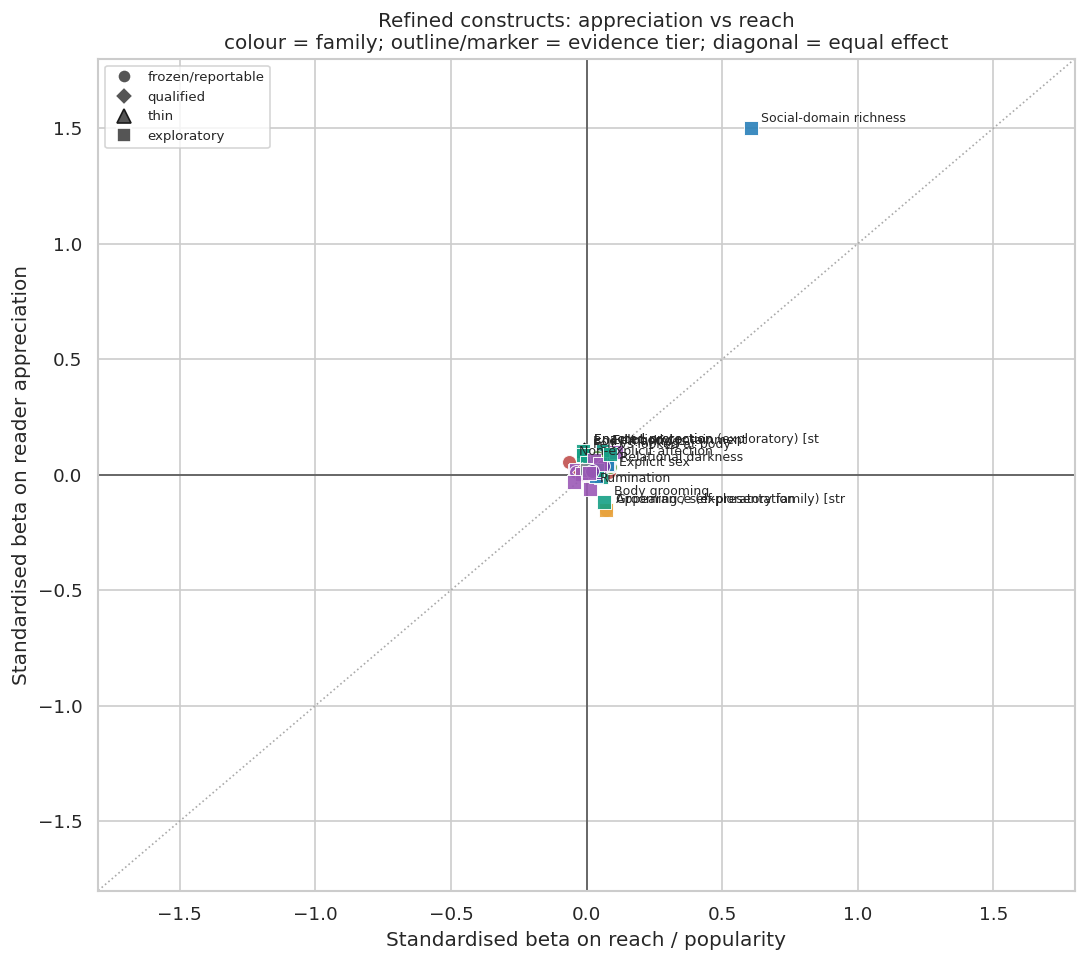

In [10]:
# Main Figure 1 — quadrant
plot_df = betas_wide[
    betas_wide["preferred_for_main_plot"].fillna(False)
    & betas_wide["quality_beta"].notna()
    & betas_wide["reach_beta"].notna()
].copy()
# Ensure a few work-screen points appear in a secondary overlay later; main uses preferred
FAMILY_COLORS = {
    "security": "#7030a0",
    "intimacy": "#c0504d",
    "appearance": "#e8a33d",
    "protection": "#4f81bd",
    "danger": "#c0504d",
    "darkness_tenderness": "#6aa84f",
    "emotion": "#9b59b6",
    "embodiment": "#16a085",
    "social": "#2980b9",
    "emotional_security": "#7030a0",
    "enacted_protection": "#4f81bd",
    "practical_care": "#8e44ad",
    "possessive_security": "#7f8c8d",
    "material_security": "#a569bd",
    "protective_commitment": "#85929e",
    "work": "#95a5a6",
    "richness": "#34495e",
    "arc": "#7f8c8d",
    "payoff": "#7f8c8d",
}
TIER_MARKERS = {
    "frozen_reportable": "o",
    "qualified": "D",
    "thin": "^",
    "exploratory": "s",
    "exploratory_moderate": "P",
    "exploratory_screen": "X",
}

fig, ax = plt.subplots(figsize=(10.5, 9))
for _, row in plot_df.iterrows():
    ax.scatter(
        row["reach_beta"],
        row["quality_beta"],
        s=70,
        color=FAMILY_COLORS.get(row["family"], "#888888"),
        marker=TIER_MARKERS.get(row["evidence_tier"], "o"),
        edgecolor="black" if row["evidence_tier"] == "thin" else "white",
        linewidth=1.0 if row["evidence_tier"] == "thin" else 0.6,
        zorder=3,
        alpha=0.9,
    )
ax.axhline(0, color="#555555", lw=1)
ax.axvline(0, color="#555555", lw=1)
limit = float(
    np.nanmax(np.abs(np.concatenate([plot_df["reach_beta"], plot_df["quality_beta"]])))
) * 1.2
ax.plot([-limit, limit], [-limit, limit], color="#aaaaaa", ls=":", lw=1, label="appreciation = reach")
# Label ~12–15 most informative
score = plot_df[["quality_beta", "reach_beta"]].abs().max(axis=1)
# Prefer gaps for informativeness
score = 0.6 * plot_df["abs_beta_gap"].fillna(0) + 0.4 * score
notable = plot_df.reindex(score.nlargest(14).index)
for row in notable.itertuples():
    ax.annotate(
        row.display_label[:36],
        (row.reach_beta, row.quality_beta),
        textcoords="offset points",
        xytext=(6, 4),
        fontsize=7.5,
    )
ax.set_xlim(-limit, limit)
ax.set_ylim(-limit, limit)
ax.set_xlabel("Standardised beta on reach / popularity")
ax.set_ylabel("Standardised beta on reader appreciation")
ax.set_title(
    "Refined constructs: appreciation vs reach\n"
    "colour = family; outline/marker = evidence tier; diagonal = equal effect"
)
# Compact legend for tiers
from matplotlib.lines import Line2D

legend_elems = [
    Line2D([0], [0], marker="o", color="w", markerfacecolor="#555", label="frozen/reportable", markersize=8),
    Line2D([0], [0], marker="D", color="w", markerfacecolor="#555", label="qualified", markersize=8),
    Line2D([0], [0], marker="^", color="w", markerfacecolor="#555", markeredgecolor="k", label="thin", markersize=8),
    Line2D([0], [0], marker="s", color="w", markerfacecolor="#555", label="exploratory", markersize=8),
]
ax.legend(handles=legend_elems, fontsize=8, loc="upper left")
ctx.save_figure(fig, "02_refined_quality_reach_quadrant")
plt.show()

  saved figure: results/stage11_refined_construct_analysis/v4_l12_granular_final_call49/notebook_analysis/16_refined_goodreads_quality_reach/figures/03_refined_quality_reach_dumbbell.png


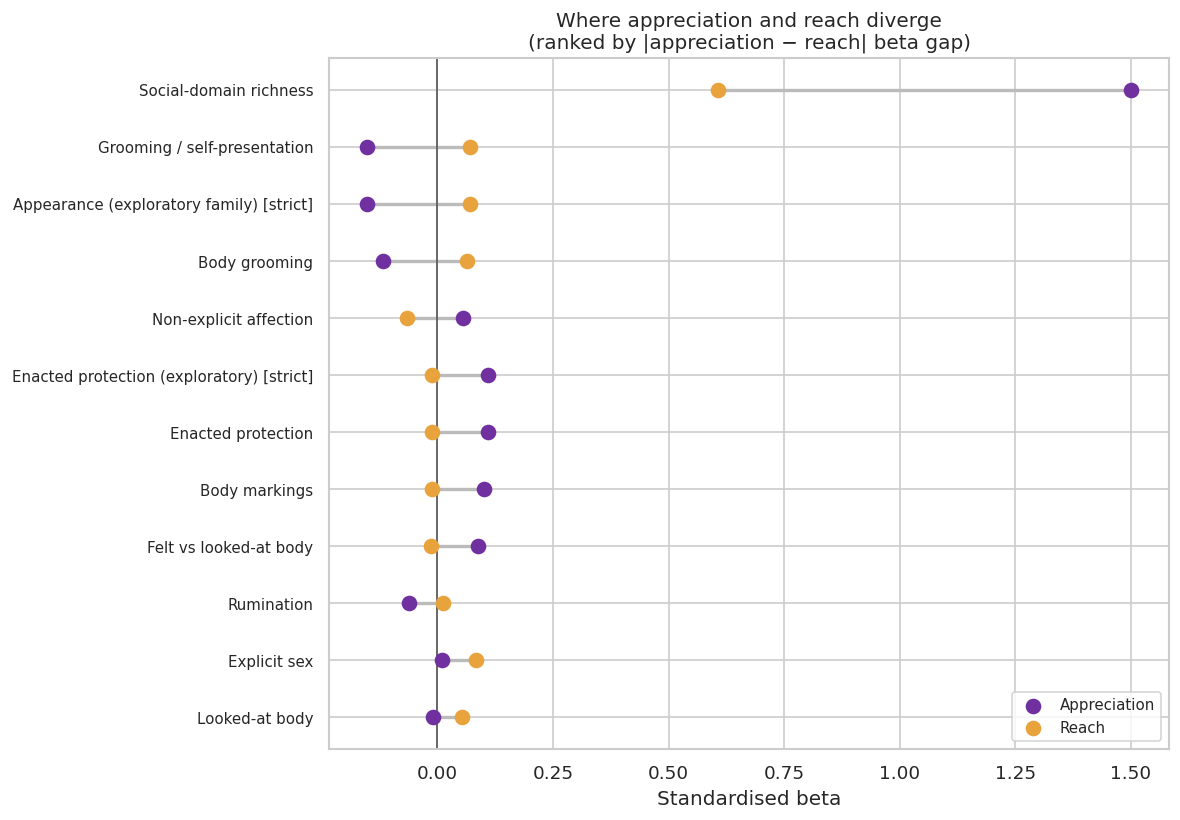

In [11]:
# Main Figure 2 — dumbbell by abs_beta_gap
dumb = plot_df.dropna(subset=["quality_beta", "reach_beta"]).copy()
dumb = dumb.sort_values("abs_beta_gap", ascending=True).tail(12)
fig, ax = plt.subplots(figsize=(10, 7))
y = np.arange(len(dumb))
for i, row in enumerate(dumb.itertuples()):
    ax.plot([row.quality_beta, row.reach_beta], [i, i], color="#bbbbbb", lw=2, zorder=1)
    ax.scatter(row.quality_beta, i, color="#7030a0", s=70, zorder=3, label="Appreciation" if i == 0 else None)
    ax.scatter(row.reach_beta, i, color="#e8a33d", s=70, zorder=3, label="Reach" if i == 0 else None)
ax.axvline(0, color="#555555", lw=1)
ax.set_yticks(y)
ax.set_yticklabels(dumb["display_label"].tolist(), fontsize=9)
ax.set_xlabel("Standardised beta")
ax.set_title("Where appreciation and reach diverge\n(ranked by |appreciation − reach| beta gap)")
ax.legend(fontsize=9, loc="lower right")
fig.tight_layout()
ctx.save_figure(fig, "03_refined_quality_reach_dumbbell")
plt.show()

## 5. What changed after semantic refinement?

Manual Stage 10 → Stage 11 channel crosswalk. Stage 10 coordinates loaded from saved
Notebook 06 tables (not recomputed).

In [12]:
stage10_path = (
    root
    / "results/stage10_correlation_analysis/v4_l12_granular_final_call49"
    / "notebook_analysis/06_goodreads_validation/tables/leaf_two_channel_betas.csv"
)
stage10_deltas_path = (
    root
    / "results/stage10_correlation_analysis/v4_l12_granular_final_call49"
    / "notebook_analysis/06_goodreads_validation/tables/leaf_deltas_both_tierings.csv"
)
s10 = pd.read_csv(stage10_path) if stage10_path.exists() else pd.DataFrame()
s10_d = pd.read_csv(stage10_deltas_path) if stage10_deltas_path.exists() else pd.DataFrame()

CROSSWALK = [
    {
        "concept": "appearance",
        "stage10_feature": "abs_leaf_1.6",
        "stage10_label": "Character Appearance & Self-Presentation",
        "stage11_features": [
            "RAX_appearance_grooming",
            "EES_body_external_appearance",
            "EES_body_grooming",
            "EES_looked_at_body",
        ],
        "question": "Was the old negative appreciation effect generic appearance or specifically grooming/self-presentation?",
    },
    {
        "concept": "emotional_safety_care",
        "stage10_feature": "abs_leaf_4.6",
        "stage10_label": "Emotional Safety, Reassurance & Caretaking",
        "stage11_features": [
            "RAX_emotional_reassurance",
            "RAX_h3_emotional_side",
            "EES_emotion_coregulation",
            "EXP_practical_care_strict",
            "RAX_external_protection",
        ],
        "question": "Does broad care separate into appreciation-oriented reassurance vs reach-oriented/neutral care?",
    },
    {
        "concept": "violence_danger",
        "stage10_feature": "abs_leaf_7.2",
        "stage10_label": "Violence, Threats & Non-Sexual Coercion",
        "stage11_features": [
            "RAX_external_danger_crisis",
            "RAX_external_protection",
            "RAX_relational_darkness",
            "RAX_h4_possession_side",
        ],
        "question": "Is the old violence signal external stakes, enacted protection, relational darkness, or a mix?",
    },
    {
        "concept": "sexuality",
        "stage10_feature": "abs_leaf_2.3",
        "stage10_label": "Explicit Sexual Acts",
        "stage11_features": [
            "RAX_explicit_sex",
            "RAX_nonexplicit_affection",
            "RLR_emotional_vs_explicit",
        ],
        "question": "Does the Stage-10 reach signal for explicit sex survive refinement while appreciation stays weaker?",
    },
    {
        "concept": "family_social",
        "stage10_feature": "abs_leaf_5.1",
        "stage10_label": "Family, Kinship & Parenthood",
        "stage11_features": [
            "EES_family_presence",
            "EES_supportive_social_embeddedness",
            "EES_social_pressure_conflict",
        ],
        "question": "Is reach associated with family presence generally, or with particular social functions?",
    },
    {
        "concept": "work_market",
        "stage10_feature": "",
        "stage10_label": "Work / institutional leaves (broad)",
        "stage11_features": [
            "EES_work_transactional_business",
            "EES_work_economic_pressure",
            "EES_work_hierarchy_power",
            "EES_work_institutional_setting",
            "EES_work_occupational_competence",
        ],
        "question": "Are work/market themes appreciation differences, reach differences, or neither?",
    },
]

cw_rows = []
s10_idx = s10.set_index("feature") if not s10.empty and "feature" in s10.columns else pd.DataFrame()
b11 = betas_wide.set_index("feature")
reg_label = registry.set_index("feature")["display_label"].to_dict()
reg_gate = registry.set_index("feature")["measurement_gate"].to_dict()
for item in CROSSWALK:
    s10_q = s10_r = s10_pat = np.nan
    if item["stage10_feature"] and item["stage10_feature"] in s10_idx.index:
        s10_q = float(s10_idx.loc[item["stage10_feature"], "quality_beta"])
        s10_r = float(s10_idx.loc[item["stage10_feature"], "reach_beta"])
        s10_pat = (
            s10_idx.loc[item["stage10_feature"], "pattern"]
            if "pattern" in s10_idx.columns
            else np.nan
        )
    for feat in item["stage11_features"]:
        if feat not in b11.index:
            cw_rows.append(
                {
                    "concept": item["concept"],
                    "question": item["question"],
                    "stage10_feature": item["stage10_feature"],
                    "stage10_label": item["stage10_label"],
                    "stage10_quality_beta": s10_q,
                    "stage10_reach_beta": s10_r,
                    "stage10_pattern": s10_pat,
                    "stage11_feature": feat,
                    "stage11_label": reg_label.get(feat, feat),
                    "stage11_quality_beta": np.nan,
                    "stage11_reach_beta": np.nan,
                    "stage11_pattern": "absent_or_unmeasurable",
                    "measurement_gate": reg_gate.get(feat, "unknown"),
                }
            )
            continue
        r = b11.loc[feat]
        if isinstance(r, pd.DataFrame):
            r = r.iloc[0]
        cw_rows.append(
            {
                "concept": item["concept"],
                "question": item["question"],
                "stage10_feature": item["stage10_feature"],
                "stage10_label": item["stage10_label"],
                "stage10_quality_beta": s10_q,
                "stage10_reach_beta": s10_r,
                "stage10_pattern": s10_pat,
                "stage11_feature": feat,
                "stage11_label": r.get("display_label", feat),
                "stage11_quality_beta": r.get("quality_beta"),
                "stage11_reach_beta": r.get("reach_beta"),
                "stage11_pattern": r.get("channel_pattern"),
                "measurement_gate": r.get("measurement_gate"),
            }
        )
crosswalk = pd.DataFrame(cw_rows)
ctx.save_table(crosswalk, "stage10_stage11_channel_crosswalk")
display(crosswalk.round(4))

  saved table: results/stage11_refined_construct_analysis/v4_l12_granular_final_call49/notebook_analysis/16_refined_goodreads_quality_reach/tables/stage10_stage11_channel_crosswalk.csv  (24 rows)


,concept,question,stage10_feature,stage10_label,stage10_quality_beta,stage10_reach_beta,stage10_pattern,stage11_feature,stage11_label,stage11_quality_beta,stage11_reach_beta,stage11_pattern,measurement_gate
0,appearance,Was the old negative appreciation effect gener...,abs_leaf_1.6,Character Appearance & Self-Presentation,-0.1390,-0.0033,quality only,RAX_appearance_grooming,Grooming / self-presentation,-0.1517,0.0703,opposite_signs,viable
1,appearance,Was the old negative appreciation effect gener...,abs_leaf_1.6,Character Appearance & Self-Presentation,-0.1390,-0.0033,quality only,EES_body_external_appearance,External appearance,0.0216,0.0388,reach_only,viable
2,appearance,Was the old negative appreciation effect gener...,abs_leaf_1.6,Character Appearance & Self-Presentation,-0.1390,-0.0033,quality only,EES_body_grooming,Body grooming,-0.1172,0.0638,opposite_signs,viable
3,appearance,Was the old negative appreciation effect gener...,abs_leaf_1.6,Character Appearance & Self-Presentation,-0.1390,-0.0033,quality only,EES_looked_at_body,Looked-at body,-0.0105,0.0523,reach_only,viable
4,emotional_safety_care,Does broad care separate into appreciation-ori...,abs_leaf_4.6,"Emotional Safety, Reassurance & Caretaking",0.0521,0.0092,quality only,RAX_emotional_reassurance,Emotional reassurance,0.0378,0.0591,both_same_sign,viable
5,emotional_safety_care,Does broad care separate into appreciation-ori...,abs_leaf_4.6,"Emotional Safety, Reassurance & Caretaking",0.0521,0.0092,quality only,RAX_h3_emotional_side,Emotional security / reassurance,0.0170,0.0196,neither,viable
6,emotional_safety_care,Does broad care separate into appreciation-ori...,abs_leaf_4.6,"Emotional Safety, Reassurance & Caretaking",0.0521,0.0092,quality only,EES_emotion_coregulation,Interpersonal co-regulation,0.0459,0.0503,both_same_sign,viable
7,emotional_safety_care,Does broad care separate into appreciation-ori...,abs_leaf_4.6,"Emotional Safety, Reassurance & Caretaking",0.0521,0.0092,quality only,EXP_practical_care_strict,Practical care [strict],0.0140,-0.0436,reach_only,viable
8,emotional_safety_care,Does broad care separate into appreciation-ori...,abs_leaf_4.6,"Emotional Safety, Reassurance & Caretaking",0.0521,0.0092,quality only,RAX_external_protection,Enacted protection,0.1089,-0.0110,quality_only,thin
9,violence_danger,"Is the old violence signal external stakes, en...",abs_leaf_7.2,"Violence, Threats & Non-Sexual Coercion",0.1391,0.0071,quality only,RAX_external_danger_crisis,External danger,0.0117,-0.0161,neither,viable


  saved figure: results/stage11_refined_construct_analysis/v4_l12_granular_final_call49/notebook_analysis/16_refined_goodreads_quality_reach/figures/06_stage10_stage11_refinement_comparison.png


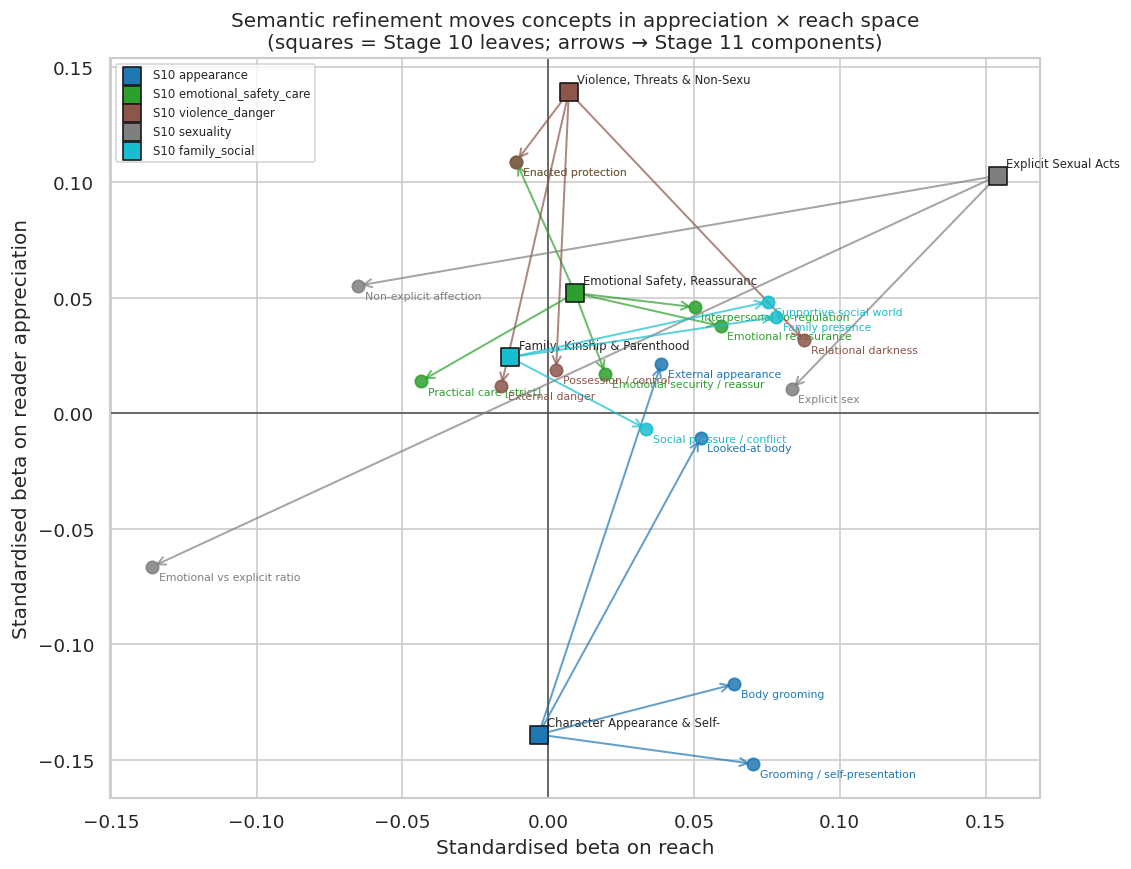

In [13]:
# Figure 6 — refinement arrows for major concepts
fig, ax = plt.subplots(figsize=(10, 8))
arrow_concepts = ["appearance", "emotional_safety_care", "violence_danger", "sexuality", "family_social"]
cmap = plt.cm.tab10
for i, concept in enumerate(arrow_concepts):
    sub = crosswalk[crosswalk["concept"] == concept]
    if sub.empty:
        continue
    color = cmap(i / max(len(arrow_concepts) - 1, 1))
    s10_q = sub["stage10_quality_beta"].iloc[0]
    s10_r = sub["stage10_reach_beta"].iloc[0]
    if np.isfinite(s10_q) and np.isfinite(s10_r):
        ax.scatter(s10_r, s10_q, s=120, marker="s", color=color, edgecolor="k", zorder=4, label=f"S10 {concept}")
        ax.annotate(sub["stage10_label"].iloc[0][:28], (s10_r, s10_q), textcoords="offset points", xytext=(5, 5), fontsize=7)
    for _, row in sub.iterrows():
        if not (np.isfinite(row["stage11_quality_beta"]) and np.isfinite(row["stage11_reach_beta"])):
            continue
        if np.isfinite(s10_q) and np.isfinite(s10_r):
            ax.annotate(
                "",
                xy=(row["stage11_reach_beta"], row["stage11_quality_beta"]),
                xytext=(s10_r, s10_q),
                arrowprops=dict(arrowstyle="->", color=color, lw=1.2, alpha=0.7),
            )
        ax.scatter(
            row["stage11_reach_beta"],
            row["stage11_quality_beta"],
            s=55,
            color=color,
            alpha=0.85,
            zorder=3,
        )
        ax.annotate(
            str(row["stage11_label"])[:28],
            (row["stage11_reach_beta"], row["stage11_quality_beta"]),
            textcoords="offset points",
            xytext=(4, -8),
            fontsize=6.5,
            color=color,
        )
ax.axhline(0, color="#555", lw=1)
ax.axvline(0, color="#555", lw=1)
ax.set_xlabel("Standardised beta on reach")
ax.set_ylabel("Standardised beta on reader appreciation")
ax.set_title("Semantic refinement moves concepts in appreciation × reach space\n(squares = Stage 10 leaves; arrows → Stage 11 components)")
ax.legend(fontsize=7, loc="best")
ctx.save_figure(fig, "06_stage10_stage11_refinement_comparison")
plt.show()

## 6. Rating tiers versus reach tiers

Secondary descriptive Cliff's δ comparison (book-level bootstrap). The |δ| ≥ 0.11 gate
applies **only** here — not to regression betas.

In [14]:
if TIER_COL not in work.columns:
    work[TIER_COL] = pd.qcut(work[QUALITY], 3, labels=["low_rate", "mid_rate", "high_rate"]).astype("string")

work["reach_class"] = pd.qcut(
    work[REACH], 3, labels=["low_reach", "mid_reach", "high_reach"]
).astype("string")
display(work["reach_class"].value_counts())

delta_feats = [
    f
    for f in measurable.loc[measurable["preferred_for_main_plot"], "feature"]
    if f in work.columns and float(work[f].std(ddof=0) or 0) > 0
]
# Include richness + work screens for the delta table completeness
extra_delta = [
    f
    for f in measurable.loc[measurable["family"].isin(["richness", "work"]), "feature"]
    if f in work.columns and float(work[f].std(ddof=0) or 0) > 0
]
delta_feats = list(dict.fromkeys(delta_feats + extra_delta))

rating_deltas = eff.two_group_effects(
    work, delta_feats, TIER_COL, HIGH, LOW, n_replicates=N_BOOT, seed=SEED
).rename(
    columns={
        "cliffs_delta": "delta_rating",
        "ci_low": "rating_ci_low",
        "ci_high": "rating_ci_high",
    }
)
reach_deltas = eff.two_group_effects(
    work, delta_feats, "reach_class", "high_reach", "low_reach", n_replicates=N_BOOT, seed=SEED
).rename(
    columns={
        "cliffs_delta": "delta_reach",
        "ci_low": "reach_ci_low",
        "ci_high": "reach_ci_high",
    }
)
channel_deltas = rating_deltas[["feature", "delta_rating", "rating_ci_low", "rating_ci_high"]].merge(
    reach_deltas[["feature", "delta_reach", "reach_ci_low", "reach_ci_high"]], on="feature"
)
channel_deltas = channel_deltas.merge(
    registry[
        ["feature", "display_label", "evidence_tier", "measurement_gate", "family", "source_notebook"]
    ],
    on="feature",
    how="left",
)
channel_deltas["rating_clears_gate"] = channel_deltas["delta_rating"].abs() >= GATE
channel_deltas["reach_clears_gate"] = channel_deltas["delta_reach"].abs() >= GATE
channel_deltas["same_direction"] = np.sign(channel_deltas["delta_rating"]) == np.sign(
    channel_deltas["delta_reach"]
)
channel_deltas = channel_deltas.sort_values("delta_rating", ascending=False).reset_index(drop=True)
ctx.save_table(channel_deltas, "refined_rating_vs_reach_deltas")

agree = channel_deltas[["delta_rating", "delta_reach"]].dropna()
r_d = sps.pearsonr(agree["delta_rating"], agree["delta_reach"])
rho_d = sps.spearmanr(agree["delta_rating"], agree["delta_reach"])
print(
    f"δ vectors: Pearson r = {r_d[0]:+.3f}, Spearman ρ = {rho_d[0]:+.3f}\n"
    f"Same-sign: {int(channel_deltas['same_direction'].sum())} / {len(channel_deltas)}\n"
    f"Clearing gate {GATE}: "
    f"rating {int(channel_deltas['rating_clears_gate'].sum())}, "
    f"reach {int(channel_deltas['reach_clears_gate'].sum())}, "
    f"both {int((channel_deltas['rating_clears_gate'] & channel_deltas['reach_clears_gate']).sum())}"
)
print("Note: book-level bootstrap CIs — secondary descriptive comparison.")

reach_class
low_reach     5416
high_reach    5320
mid_reach     5263
Name: count, dtype: Int64

  saved table: results/stage11_refined_construct_analysis/v4_l12_granular_final_call49/notebook_analysis/16_refined_goodreads_quality_reach/tables/refined_rating_vs_reach_deltas.csv  (50 rows)
δ vectors: Pearson r = +0.330, Spearman ρ = +0.378
Same-sign: 38 / 50
Clearing gate 0.11: rating 16, reach 11, both 5
Note: book-level bootstrap CIs — secondary descriptive comparison.


  saved figure: results/stage11_refined_construct_analysis/v4_l12_granular_final_call49/notebook_analysis/16_refined_goodreads_quality_reach/figures/04_rating_vs_reach_deltas.png


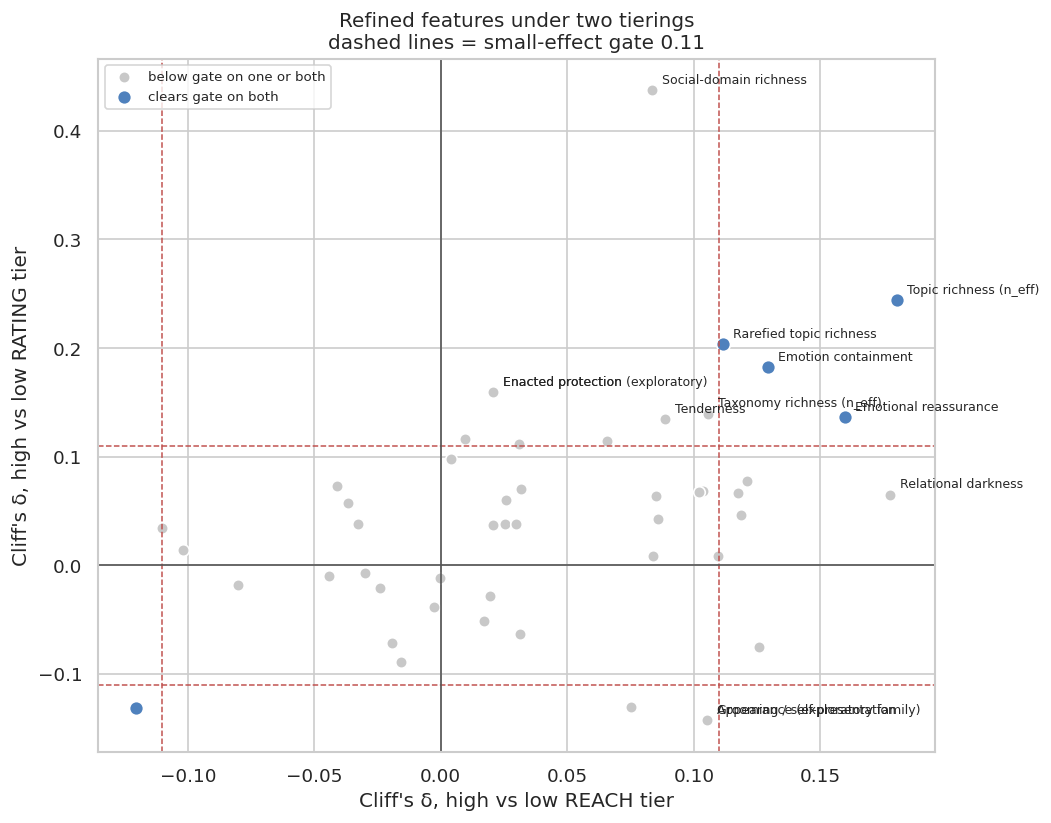

In [15]:
fig, ax = plt.subplots(figsize=(9, 7.5))
both = channel_deltas["rating_clears_gate"] & channel_deltas["reach_clears_gate"]
ax.scatter(
    channel_deltas.loc[~both, "delta_reach"],
    channel_deltas.loc[~both, "delta_rating"],
    s=48,
    color="#c8c8c8",
    edgecolor="white",
    label="below gate on one or both",
)
ax.scatter(
    channel_deltas.loc[both, "delta_reach"],
    channel_deltas.loc[both, "delta_rating"],
    s=70,
    color="#4f81bd",
    edgecolor="white",
    label="clears gate on both",
)
for level in (GATE, -GATE):
    ax.axhline(level, color="#c0504d", ls="--", lw=0.9)
    ax.axvline(level, color="#c0504d", ls="--", lw=0.9)
ax.axhline(0, color="#555", lw=1)
ax.axvline(0, color="#555", lw=1)
for row in channel_deltas.reindex(
    channel_deltas[["delta_rating", "delta_reach"]].abs().max(axis=1).nlargest(12).index
).itertuples():
    ax.annotate(
        str(row.display_label)[:32],
        (row.delta_reach, row.delta_rating),
        textcoords="offset points",
        xytext=(6, 4),
        fontsize=7.5,
    )
ax.set_xlabel("Cliff's δ, high vs low REACH tier")
ax.set_ylabel("Cliff's δ, high vs low RATING tier")
ax.set_title("Refined features under two tierings\ndashed lines = small-effect gate 0.11")
ax.legend(fontsize=8, loc="upper left")
ctx.save_figure(fig, "04_rating_vs_reach_deltas")
plt.show()

## 7. Hidden gems, stars, and popular-but-less-liked books

Residual Goodreads quadrants after year, length, and genre. Theme means are
z-scored across quadrants for the heatmap.

  saved table: results/stage11_refined_construct_analysis/v4_l12_granular_final_call49/notebook_analysis/16_refined_goodreads_quality_reach/tables/residual_quadrant_counts.csv  (4 rows)


,residual_quadrant,n_books
0,stars,4383
1,low_low,4382
2,popular_but_poor,3617
3,hidden_gems,3617


  saved table: results/stage11_refined_construct_analysis/v4_l12_granular_final_call49/notebook_analysis/16_refined_goodreads_quality_reach/tables/residual_quadrant_feature_means.csv  (40 rows)


  saved figure: results/stage11_refined_construct_analysis/v4_l12_granular_final_call49/notebook_analysis/16_refined_goodreads_quality_reach/figures/05_residual_quadrant_theme_heatmap.png


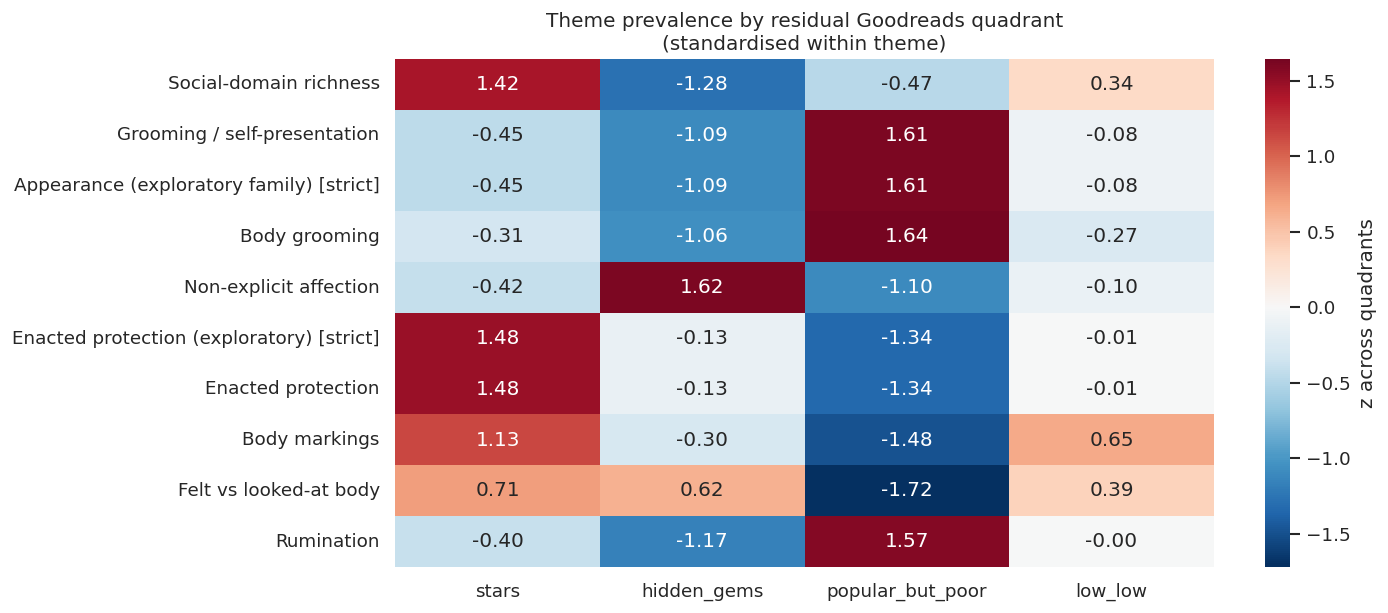

  saved table: results/stage11_refined_construct_analysis/v4_l12_granular_final_call49/notebook_analysis/16_refined_goodreads_quality_reach/tables/residual_quadrant_feature_deltas.csv  (27 rows)


,feature,display_label,contrast,cliffs_delta,n_a,n_b
0,RAX_appearance_grooming,Grooming / self-presentation,hidden_gems_vs_popular_but_poor,-0.1721,3617,3617
1,RAX_appearance_grooming,Grooming / self-presentation,stars_vs_popular_but_poor,-0.1181,4383,3617
2,RAX_appearance_grooming,Grooming / self-presentation,hidden_gems_vs_low_low,-0.0644,3617,4382
3,EXP_appearance_strict,Appearance (exploratory family) [strict],hidden_gems_vs_popular_but_poor,-0.1721,3617,3617
4,EXP_appearance_strict,Appearance (exploratory family) [strict],stars_vs_popular_but_poor,-0.1181,4383,3617
5,EXP_appearance_strict,Appearance (exploratory family) [strict],hidden_gems_vs_low_low,-0.0644,3617,4382
6,EES_body_grooming,Body grooming,hidden_gems_vs_popular_but_poor,-0.1351,3617,3617
7,EES_body_grooming,Body grooming,stars_vs_popular_but_poor,-0.0816,4383,3617
8,EES_body_grooming,Body grooming,hidden_gems_vs_low_low,-0.0419,3617,4382
9,RAX_nonexplicit_affection,Non-explicit affection,hidden_gems_vs_popular_but_poor,0.1233,3617,3617


In [16]:
quad_counts = (
    work["residual_quadrant"].value_counts().rename_axis("residual_quadrant").reset_index(name="n_books")
)
ctx.save_table(quad_counts, "residual_quadrant_counts")
display(quad_counts)

heat_feats = list(
    plot_df.sort_values("abs_beta_gap", ascending=False)["feature"].head(10)
)
heat_feats = [f for f in heat_feats if f in work.columns]
quad_means = pres.quadrant_theme_means(work, heat_feats)
# Long form for saving
qm_long = quad_means.melt(id_vars=["quadrant", "n_books"], var_name="feature", value_name="mean_share")
qm_long = qm_long.merge(registry[["feature", "display_label"]], on="feature", how="left")
ctx.save_table(qm_long, "residual_quadrant_feature_means")

# Z-score each theme across quadrants
mat = quad_means.set_index("quadrant")[heat_feats]
mat_z = mat.apply(lambda s: (s - s.mean()) / s.std(ddof=0) if s.std(ddof=0) > 0 else s * 0, axis=0)
mat_z = mat_z.rename(columns=label_map)
order = [q for q in ("stars", "hidden_gems", "popular_but_poor", "low_low") if q in mat_z.index]
mat_z = mat_z.reindex(order)

fig, ax = plt.subplots(figsize=(11, 5.5))
sns.heatmap(mat_z.T, cmap="RdBu_r", center=0, annot=True, fmt=".2f", ax=ax, cbar_kws={"label": "z across quadrants"})
ax.set_title("Theme prevalence by residual Goodreads quadrant\n(standardised within theme)")
ax.set_xlabel("")
ctx.save_figure(fig, "05_residual_quadrant_theme_heatmap")
plt.show()

# Contrasts: hidden gems vs popular_but_poor (key), stars vs popular_but_poor, hidden vs low_low
from src.stage10_correlation_analysis.analysis.effects import cliffs_delta

contrast_defs = [
    ("hidden_gems", "popular_but_poor"),
    ("stars", "popular_but_poor"),
    ("hidden_gems", "low_low"),
]
delta_rows = []
for feat in heat_feats:
    for a, b in contrast_defs:
        aa = work.loc[work["residual_quadrant"] == a, feat].dropna().to_numpy(float)
        bb = work.loc[work["residual_quadrant"] == b, feat].dropna().to_numpy(float)
        if aa.size < 20 or bb.size < 20:
            continue
        d = float(cliffs_delta(aa, bb))
        delta_rows.append(
            {
                "feature": feat,
                "display_label": label_map.get(feat, feat),
                "contrast": f"{a}_vs_{b}",
                "cliffs_delta": d,
                "n_a": int(aa.size),
                "n_b": int(bb.size),
            }
        )
quad_deltas = pd.DataFrame(delta_rows)
ctx.save_table(quad_deltas, "residual_quadrant_feature_deltas")
display(quad_deltas.round(4).head(30))

## 8–12. Family channel profiles

Emotion / embodiment / social world; security, care, danger, protection;
appearance (generic vs grooming); sex and intimacy; work screen.
Interpretations are generated only from executed coefficients.

### Emotion / embodiment / social world


,display_label,quality_beta,quality_reliable,reach_beta,reach_reliable,beta_gap,channel_pattern,measurement_gate,evidence_tier
0,Social-domain richness,1.5001,False,0.6061,False,0.8940,neither,viable,exploratory
4,Body grooming,-0.1172,True,0.0638,True,-0.1810,opposite_signs,viable,exploratory
12,Body markings,0.1014,True,-0.0115,False,0.1130,quality_only,thin,exploratory
13,Felt vs looked-at body,0.0867,True,-0.0146,False,0.1013,quality_only,viable,exploratory
20,Rumination,-0.0609,True,0.0130,False,-0.0739,quality_only,thin,exploratory
25,Looked-at body,-0.0105,False,0.0523,True,-0.0628,reach_only,viable,exploratory
32,Physical comfort,0.0184,False,-0.0371,True,0.0556,reach_only,viable,exploratory
34,Individual distress,0.0101,False,-0.0403,True,0.0503,reach_only,viable,frozen_reportable
35,Vulnerable body,0.0498,True,0.0022,False,0.0476,quality_only,viable,exploratory
36,Emotion containment,0.1062,True,0.0589,True,0.0473,both_same_sign,viable,exploratory



### Security / care / danger / protection


,display_label,quality_beta,quality_reliable,reach_beta,reach_reliable,beta_gap,channel_pattern,measurement_gate,evidence_tier
6,Enacted protection (exploratory) [broad],0.1487,True,-0.0254,False,0.1741,quality_only,viable,exploratory
7,Enacted protection (exploratory) [moderate],0.1437,True,-0.0207,False,0.1645,quality_only,viable,exploratory_moderate
10,Enacted protection (exploratory) [strict],0.1089,True,-0.0110,False,0.1199,quality_only,thin,thin
11,Enacted protection,0.1089,True,-0.0110,False,0.1199,quality_only,thin,thin
19,Practical care [broad],0.0440,True,-0.0315,True,0.0755,opposite_signs,viable,exploratory
26,Practical care [moderate],0.0146,False,-0.0481,True,0.0627,reach_only,viable,exploratory_moderate
27,Material security (exploratory) [moderate],-0.1182,True,-0.0562,True,-0.0620,both_same_sign,viable,exploratory_moderate
28,Protection vs possession,0.0244,False,-0.0358,True,0.0602,reach_only,thin,thin
30,Practical care [strict],0.0140,False,-0.0436,True,0.0575,reach_only,viable,exploratory
40,Material security (exploratory) [broad],-0.0899,True,-0.0515,True,-0.0384,both_same_sign,viable,exploratory



### Appearance


...


### Sex and intimacy


,display_label,quality_beta,quality_reliable,reach_beta,reach_reliable,beta_gap,channel_pattern,measurement_gate,evidence_tier
9,Non-explicit affection,0.0553,True,-0.0651,True,0.1204,opposite_signs,viable,frozen_reportable
21,Explicit sex,0.0105,False,0.0835,True,-0.0730,reach_only,viable,frozen_reportable
22,Emotional vs explicit ratio,-0.0663,True,-0.1358,True,0.0695,both_same_sign,viable,frozen_reportable



### Work / market-world screen


,display_label,quality_beta,quality_reliable,reach_beta,reach_reliable,beta_gap,channel_pattern,measurement_gate,evidence_tier
8,Economic pressure,-0.1631,True,-0.0421,True,-0.1210,both_same_sign,viable,exploratory_screen
15,Transactional business talk,-0.1074,True,-0.0238,True,-0.0836,both_same_sign,viable,exploratory_screen
17,Hierarchy / power,0.0177,False,-0.0623,True,0.0799,reach_only,viable,exploratory_screen
23,Generic logistics,-0.0932,True,-0.0290,True,-0.0642,both_same_sign,viable,exploratory_screen
37,Institutional setting,-0.0234,False,-0.0648,True,0.0414,reach_only,viable,exploratory_screen
42,Occupational competence,-0.0675,True,-0.0310,True,-0.0365,both_same_sign,viable,exploratory_screen
68,Status / wealth,-0.0939,True,-0.0876,True,-0.0063,both_same_sign,thin,exploratory_screen
70,Shared work,-0.0284,False,-0.0320,True,0.0037,reach_only,viable,exploratory_screen


  saved figure: results/stage11_refined_construct_analysis/v4_l12_granular_final_call49/notebook_analysis/16_refined_goodreads_quality_reach/figures/09_family_facets_quality_reach.png


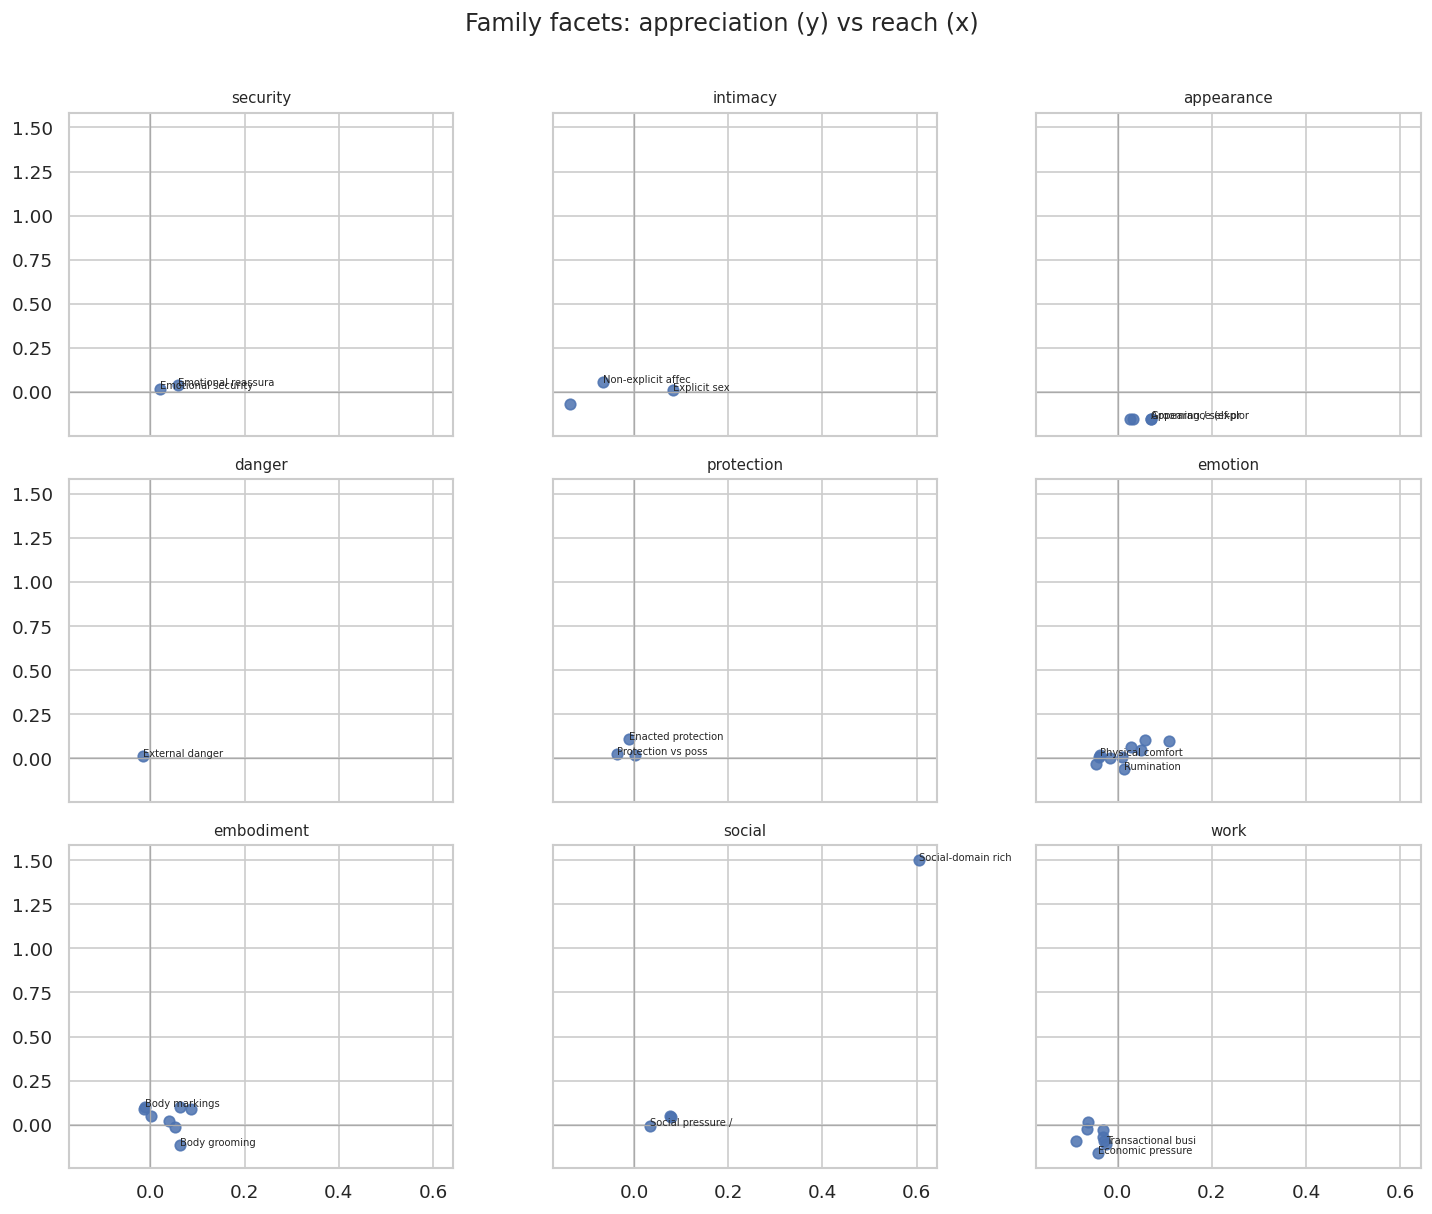

In [17]:
def _profile_block(family_keys, title):
    sub = betas_wide[betas_wide["family"].isin(family_keys)].copy()
    if sub.empty:
        print(f"{title}: no rows")
        return sub
    cols = [
        "display_label",
        "quality_beta",
        "quality_reliable",
        "reach_beta",
        "reach_reliable",
        "beta_gap",
        "channel_pattern",
        "measurement_gate",
        "evidence_tier",
    ]
    display(sub[cols].round(4))
    return sub


print("### Emotion / embodiment / social world")
_profile_block(["emotion", "embodiment", "social"], "EES")
print("\n### Security / care / danger / protection")
_profile_block(
    ["security", "protection", "danger", "emotional_security", "enacted_protection", "practical_care", "possessive_security", "material_security", "protective_commitment"],
    "Security",
)
print("\n### Appearance")
_profile_block(["appearance"], "Appearance")
print("\n### Sex and intimacy")
_profile_block(["intimacy"], "Intimacy")
print("\n### Work / market-world screen")
work_prof = _profile_block(["work"], "Work")

# Optional family facets figure
facet_families = ["security", "intimacy", "appearance", "danger", "protection", "emotion", "embodiment", "social", "work"]
facet = betas_wide[betas_wide["family"].isin(facet_families) & betas_wide["quality_beta"].notna()].copy()
if not facet.empty:
    fig, axes = plt.subplots(3, 3, figsize=(12, 10), sharex=True, sharey=True)
    for ax, fam in zip(axes.ravel(), facet_families):
        sub = facet[facet["family"] == fam]
        ax.scatter(sub["reach_beta"], sub["quality_beta"], s=40, alpha=0.85)
        ax.axhline(0, color="#aaa", lw=0.8)
        ax.axvline(0, color="#aaa", lw=0.8)
        ax.set_title(fam, fontsize=9)
        for row in sub.reindex(sub["abs_beta_gap"].nlargest(2).index).itertuples():
            ax.annotate(str(row.display_label)[:18], (row.reach_beta, row.quality_beta), fontsize=6)
    fig.suptitle("Family facets: appreciation (y) vs reach (x)", y=1.01)
    fig.tight_layout()
    ctx.save_figure(fig, "09_family_facets_quality_reach")
    plt.show()

## 13. Thematic richness versus the two channels

Raw richness is length-sensitive. Controls and rarefaction are mandatory before claiming
that thematic breadth distinguishes appreciation or reach.

  saved table: results/stage11_refined_construct_analysis/v4_l12_granular_final_call49/notebook_analysis/16_refined_goodreads_quality_reach/tables/richness_two_channel.csv  (5 rows)


,feature,quality_beta,quality_se,quality_p,quality_ci_low,quality_ci_high,quality_n_obs,quality_n_clusters,reach_beta,reach_se,reach_p,reach_ci_low,reach_ci_high,reach_n_obs,reach_n_clusters,beta_gap,abs_beta_gap,display_label
0,rare_taxonomy_n_eff,-0.0103,0.0166,0.5340,-0.0430,0.0223,14364,7601,0.0225,0.0109,0.0380,0.0012,0.0438,14364,7601,-0.0329,0.0329,Rarefied taxonomy richness
1,rare_topic_n_eff,0.0558,0.0190,0.0034,0.0185,0.0931,14364,7601,0.0407,0.0124,0.0010,0.0164,0.0649,14364,7601,0.0151,0.0151,Rarefied topic richness
2,taxonomy_n_eff,0.0094,0.0171,0.5824,-0.0241,0.0429,15999,8263,0.0433,0.0101,0.0000,0.0235,0.0631,15999,8263,-0.0339,0.0339,Taxonomy richness (n_eff)
3,taxonomy_top10,-0.0322,0.0168,0.0556,-0.0652,0.0008,15999,8263,-0.0676,0.0104,0.0000,-0.0880,-0.0471,15999,8263,0.0353,0.0353,Taxonomy top-10 concentration
4,topic_n_eff,0.0751,0.0199,0.0002,0.0361,0.1140,15999,8263,0.0672,0.0118,0.0000,0.0441,0.0903,15999,8263,0.0079,0.0079,Topic richness (n_eff)


  saved figure: results/stage11_refined_construct_analysis/v4_l12_granular_final_call49/notebook_analysis/16_refined_goodreads_quality_reach/figures/07_richness_quality_vs_reach.png


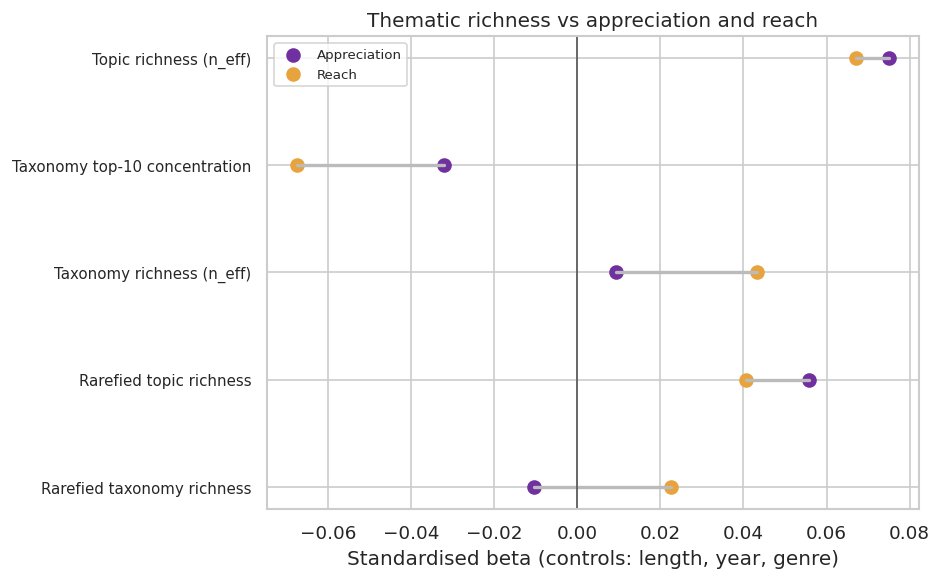

In [18]:
rich_feats = [f for f, _, _ in RICHNESS_SPECS if f in work.columns]
rich_long = pres.standardized_two_channel_betas(
    work,
    rich_feats,
    quality=QUALITY,
    reach=REACH,
    controls=NUMERIC_CONTROLS,
    quality_weights=WEIGHT,
    reach_weights=None,
    cluster=CLUSTER,
)
rich_wide = pres.pivot_two_channel_betas(rich_long)
rich_wide = rich_wide.merge(registry[["feature", "display_label"]], on="feature", how="left")
ctx.save_table(rich_wide, "richness_two_channel")
display(rich_wide.round(4))

fig, ax = plt.subplots(figsize=(8, 5))
y = np.arange(len(rich_wide))
for i, row in enumerate(rich_wide.itertuples()):
    ax.plot([row.quality_beta, row.reach_beta], [i, i], color="#bbbbbb", lw=2)
    ax.scatter(row.quality_beta, i, color="#7030a0", s=60, label="Appreciation" if i == 0 else None)
    ax.scatter(row.reach_beta, i, color="#e8a33d", s=60, label="Reach" if i == 0 else None)
ax.axvline(0, color="#555", lw=1)
ax.set_yticks(y)
ax.set_yticklabels(rich_wide["display_label"].tolist(), fontsize=9)
ax.set_xlabel("Standardised beta (controls: length, year, genre)")
ax.set_title("Thematic richness vs appreciation and reach")
ax.legend(fontsize=8)
fig.tight_layout()
ctx.save_figure(fig, "07_richness_quality_vs_reach")
plt.show()

## 14. Quality-measure sensitivity

Four specifications for top themes. Do not promote an appreciation-specific reading
that exists only under reliability-weighted shrunk rating and reverses under raw rating.

  saved table: results/stage11_refined_construct_analysis/v4_l12_granular_final_call49/notebook_analysis/16_refined_goodreads_quality_reach/tables/quality_channel_sensitivity.csv  (48 rows)


variant,"shrunk, weighted (primary)","shrunk, unweighted","raw rating, unweighted","raw rating, n >= 30",max_abs_spread,sign_stable
display_label,,,,,,
Appearance (exploratory family) [strict],-0.1517,-0.0981,-0.0980,-0.1054,0.0537,True
Body grooming,-0.1172,-0.0744,-0.0769,-0.0829,0.0428,True
Body markings,0.1014,0.0511,0.0269,0.0388,0.0746,True
Enacted protection,0.1089,0.0719,0.0651,0.0720,0.0438,True
Enacted protection (exploratory) [strict],0.1089,0.0719,0.0651,0.0720,0.0438,True
Explicit sex,0.0105,-0.0140,-0.0510,-0.0463,0.0615,False
Felt vs looked-at body,0.0867,0.0411,0.0385,0.0361,0.0507,True
Grooming / self-presentation,-0.1517,-0.0981,-0.0980,-0.1054,0.0537,True
Looked-at body,-0.0105,-0.0056,-0.0067,-0.0045,0.0060,True


  saved figure: results/stage11_refined_construct_analysis/v4_l12_granular_final_call49/notebook_analysis/16_refined_goodreads_quality_reach/figures/08_quality_measure_sensitivity.png


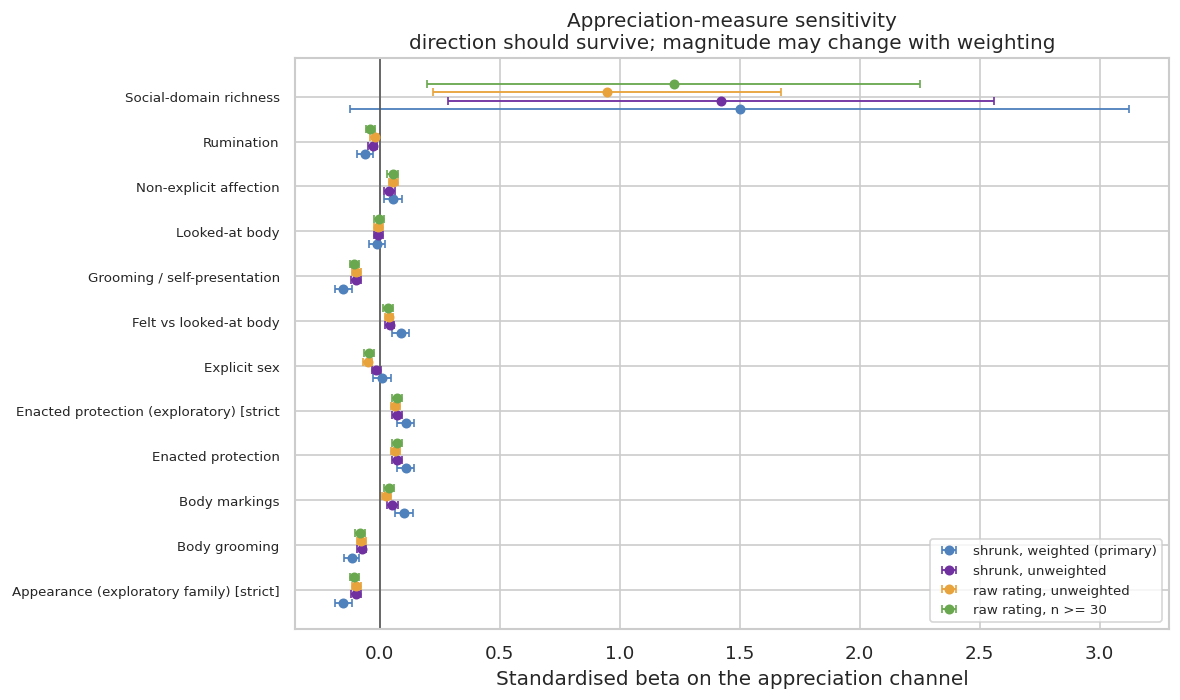

In [19]:
def _standardised(series: pd.Series) -> pd.Series:
    sd = series.std(ddof=0)
    return (series - series.mean()) / sd if sd and sd > 0 else series * 0.0


headline = list(
    betas_wide.loc[
        betas_wide["preferred_for_main_plot"].fillna(False)
        & betas_wide["measurement_gate"].ne("unmeasurable"),
        "feature",
    ].head(12)
)
headline = [f for f in headline if f in work.columns]
variants = {
    "shrunk, weighted (primary)": dict(outcome=QUALITY, weights=WEIGHT, subset=None),
    "shrunk, unweighted": dict(outcome=QUALITY, weights=None, subset=None),
    "raw rating, unweighted": dict(outcome=QUALITY_RAW, weights=None, subset=None),
    f"raw rating, n >= {MIN_RATINGS}": dict(
        outcome=QUALITY_RAW, weights=None, subset=f"n_ratings >= {MIN_RATINGS}"
    ),
}
sens_rows = []
for feat in headline:
    for name, spec in variants.items():
        subset = work.query(spec["subset"]) if spec["subset"] else work
        tmp = subset.copy()
        tmp["_y"] = _standardised(tmp[spec["outcome"]])
        tmp["_x"] = _standardised(tmp[feat])
        if tmp["_x"].std(ddof=0) == 0:
            continue
        fit = mdl.fit_ols(
            tmp,
            "_y",
            ["_x", *[c for c in NUMERIC_CONTROLS if c in tmp.columns]],
            categorical=[c for c in CATEGORICAL if c in tmp.columns],
            cluster=CLUSTER if CLUSTER in tmp.columns else None,
            weights=spec["weights"] if spec["weights"] and spec["weights"] in tmp.columns else None,
            name=f"{feat}|{name}",
        )
        row = fit.coefficients[fit.coefficients["term"] == "_x"].iloc[0]
        sens_rows.append(
            {
                "feature": feat,
                "display_label": label_map.get(feat, feat),
                "variant": name,
                "beta": float(row["coefficient"]),
                "se": float(row["std_error"]),
                "p_value": float(row["p_value"]),
                "n_obs": fit.n_obs,
            }
        )
sensitivity = pd.DataFrame(sens_rows)
ctx.save_table(sensitivity, "quality_channel_sensitivity")
wide_s = sensitivity.pivot_table(index="display_label", columns="variant", values="beta")
wide_s = wide_s[[c for c in variants if c in wide_s.columns]]
wide_s["max_abs_spread"] = wide_s.max(axis=1) - wide_s.min(axis=1)
wide_s["sign_stable"] = np.sign(wide_s[[c for c in variants if c in wide_s.columns]]).nunique(axis=1) == 1
display(wide_s.round(4))

fig, ax = plt.subplots(figsize=(10, 6))
order = wide_s.index.tolist()
offsets = np.linspace(-0.28, 0.28, len(variants))
colours = ["#4f81bd", "#7030a0", "#e8a33d", "#6aa84f"]
for offset, (name, colour) in zip(offsets, zip(variants, colours)):
    subset = sensitivity[sensitivity["variant"] == name].set_index("display_label").reindex(order)
    positions = np.arange(len(order)) + offset
    ax.errorbar(
        subset["beta"],
        positions,
        xerr=1.96 * subset["se"],
        fmt="o",
        color=colour,
        ms=5,
        capsize=2.5,
        lw=1.1,
        label=name,
    )
ax.axvline(0, color="#555", lw=1)
ax.set_yticks(np.arange(len(order)))
ax.set_yticklabels([s[:40] for s in order], fontsize=8)
ax.set_xlabel("Standardised beta on the appreciation channel")
ax.set_title("Appreciation-measure sensitivity\ndirection should survive; magnitude may change with weighting")
ax.legend(fontsize=8)
fig.tight_layout()
ctx.save_figure(fig, "08_quality_measure_sensitivity")
plt.show()

## 15. Final synthesis

Auto-generated from executed results — not hard-coded answers.

In [20]:
def _fmt_ci(lo, hi):
    if not (np.isfinite(lo) and np.isfinite(hi)):
        return ""
    return f"[{lo:.3f}, {hi:.3f}]"


def _one_sentence(row) -> str:
    q, r = row.get("quality_beta"), row.get("reach_beta")
    pat = row.get("channel_pattern")
    lab = row.get("display_label", row.get("feature"))
    if pat == "quality_only":
        return (
            f"{lab} is primarily associated with reader appreciation "
            f"(β={q:+.3f}), with little corresponding reach signal."
        )
    if pat == "reach_only":
        return (
            f"{lab} is associated more strongly with Goodreads reach "
            f"(β={r:+.3f}) than with appreciation."
        )
    if pat == "both_same_sign":
        return (
            f"{lab} moves with both appreciation (β={q:+.3f}) and reach (β={r:+.3f}) in the same direction."
        )
    if pat == "opposite_signs":
        return (
            f"{lab} shows a trade-off: appreciation β={q:+.3f} vs reach β={r:+.3f}."
        )
    # Null / neither — still useful
    if abs(q or 0) < 0.03 and abs(r or 0) < 0.03:
        return f"{lab} does not distinguish either channel strongly in this corpus."
    return (
        f"{lab} shows an inconclusive/weak channel pattern "
        f"(appreciation β={q:+.3f}, reach β={r:+.3f})."
    )


# Shortlist: prefer measurable non-thin with clear pattern or large gap + narrative relevance
NARRATIVE = {
    "RAX_emotional_reassurance",
    "RAX_h3_emotional_side",
    "RAX_tenderness_core",
    "RAX_external_danger_crisis",
    "RAX_external_protection",
    "RAX_appearance_grooming",
    "RAX_explicit_sex",
    "EES_emotion_coregulation",
    "EES_emotion_physiological_arousal",
    "EES_emotion_distress_expressed",
    "EES_supportive_social_embeddedness",
    "EES_family_presence",
    "EES_felt_body",
    "EES_looked_at_body",
    "EES_body_grooming",
    "EES_body_external_appearance",
    "EES_work_economic_pressure",
    "EES_work_transactional_business",
    "taxonomy_n_eff",
    "rare_taxonomy_n_eff",
    "EXP_practical_care_strict",
    "EXP_enacted_protection_strict",
    "RAX_relational_darkness",
    "RAX_nonexplicit_affection",
}
cand = betas_wide[
    betas_wide["measurement_gate"].ne("unmeasurable")
    & betas_wide["quality_beta"].notna()
].copy()
cand["priority"] = 0.0
cand.loc[cand["feature"].isin(NARRATIVE), "priority"] += 3.0
cand.loc[cand["channel_pattern"].isin(["quality_only", "reach_only", "opposite_signs", "both_same_sign"]), "priority"] += 2.0
cand.loc[cand["evidence_tier"].isin(["frozen_reportable", "qualified", "exploratory"]), "priority"] += 1.0
cand.loc[cand["evidence_tier"].eq("thin"), "priority"] -= 0.5
cand.loc[cand["measurement_gate"].eq("thin"), "priority"] -= 0.5
cand["priority"] += cand["abs_beta_gap"].fillna(0)
# Prefer broader measurable features
cand = cand.sort_values(["priority", "abs_beta_gap"], ascending=False)
shortlist = cand.head(12).copy()
# Ensure thin only if substantively important
shortlist = shortlist[
    ~(
        (shortlist["evidence_tier"] == "thin")
        & (~shortlist["feature"].isin({"RAX_external_protection"}))
    )
].head(12)

# Attach deltas if available
if not channel_deltas.empty:
    shortlist = shortlist.merge(
        channel_deltas[["feature", "delta_rating", "delta_reach"]],
        on="feature",
        how="left",
    )
else:
    shortlist["delta_rating"] = np.nan
    shortlist["delta_reach"] = np.nan

shortlist["quality_ci"] = [
    _fmt_ci(a, b) for a, b in zip(shortlist["quality_ci_low"], shortlist["quality_ci_high"])
]
shortlist["reach_ci"] = [
    _fmt_ci(a, b) for a, b in zip(shortlist["reach_ci_low"], shortlist["reach_ci_high"])
]
shortlist["one_sentence_interpretation"] = shortlist.apply(_one_sentence, axis=1)
out_cols = [
    "feature",
    "display_label",
    "family",
    "source_notebook",
    "evidence_tier",
    "measurement_gate",
    "quality_beta",
    "quality_ci",
    "reach_beta",
    "reach_ci",
    "beta_gap",
    "channel_pattern",
    "delta_rating",
    "delta_reach",
    "one_sentence_interpretation",
]
shortlist_out = shortlist[[c for c in out_cols if c in shortlist.columns]]
ctx.save_table(shortlist_out, "presentation_quality_reach_shortlist")
display(shortlist_out.round(4))

  saved table: results/stage11_refined_construct_analysis/v4_l12_granular_final_call49/notebook_analysis/16_refined_goodreads_quality_reach/tables/presentation_quality_reach_shortlist.csv  (12 rows)


,feature,display_label,family,source_notebook,evidence_tier,measurement_gate,quality_beta,quality_ci,reach_beta,reach_ci,beta_gap,channel_pattern,delta_rating,delta_reach,one_sentence_interpretation
0,RAX_appearance_grooming,Grooming / self-presentation,appearance,13,frozen_reportable,viable,-0.1517,"[-0.186, -0.117]",0.0703,"[0.049, 0.092]",-0.2220,opposite_signs,-0.1424,0.1052,Grooming / self-presentation shows a trade-off...
1,EES_body_grooming,Body grooming,embodiment,15,exploratory,viable,-0.1172,"[-0.148, -0.086]",0.0638,"[0.044, 0.084]",-0.1810,opposite_signs,-0.1304,0.0750,Body grooming shows a trade-off: appreciation ...
2,RAX_nonexplicit_affection,Non-explicit affection,intimacy,13,frozen_reportable,viable,0.0553,"[0.017, 0.093]",-0.0651,"[-0.090, -0.040]",0.1204,opposite_signs,0.0343,-0.1101,Non-explicit affection shows a trade-off: appr...
3,RAX_explicit_sex,Explicit sex,intimacy,13,frozen_reportable,viable,0.0105,"[-0.027, 0.048]",0.0835,"[0.058, 0.109]",-0.0730,reach_only,-0.0753,0.1258,Explicit sex is associated more strongly with ...
4,EES_looked_at_body,Looked-at body,embodiment,15,exploratory,viable,-0.0105,"[-0.045, 0.024]",0.0523,"[0.030, 0.074]",-0.0628,reach_only,-0.0629,0.0314,Looked-at body is associated more strongly wit...
5,EXP_practical_care_strict,Practical care [strict],practical_care,12,exploratory,viable,0.0140,"[-0.021, 0.049]",-0.0436,"[-0.059, -0.029]",0.0575,reach_only,0.0573,-0.0366,Practical care [strict] is associated more str...
6,RAX_relational_darkness,Relational darkness,darkness_tenderness,13,frozen_reportable,viable,0.0316,"[-0.004, 0.067]",0.0878,"[0.066, 0.110]",-0.0562,reach_only,0.0651,0.1776,Relational darkness is associated more strongl...
7,EES_felt_body,Felt body,embodiment,15,exploratory,viable,0.1029,"[0.066, 0.140]",0.0621,"[0.038, 0.086]",0.0408,both_same_sign,0.0641,0.0851,Felt body moves with both appreciation (β=+0.1...
8,RAX_tenderness_core,Tenderness,darkness_tenderness,13,frozen_reportable,viable,0.0754,"[0.043, 0.108]",0.0386,"[0.017, 0.060]",0.0368,both_same_sign,0.1347,0.0886,Tenderness moves with both appreciation (β=+0....
9,EES_family_presence,Family presence,social,15,exploratory,viable,0.0418,"[0.013, 0.071]",0.0781,"[0.060, 0.096]",-0.0363,both_same_sign,0.0464,0.1188,Family presence moves with both appreciation (...


In [21]:
# Synthesis A–E from results
def _list_pattern(pattern, n=8):
    sub = betas_wide[betas_wide["channel_pattern"] == pattern].copy()
    sub = sub[sub["measurement_gate"] != "unmeasurable"]
    return sub.head(n)


lines = ["# Synthesis — What gets liked is not necessarily what gets reached\n"]
lines.append("## A. Appreciation-specific\n")
for _, r in _list_pattern("quality_only").iterrows():
    lines.append(f"- {_one_sentence(r)}")
lines.append("\n## B. Reach-specific\n")
for _, r in _list_pattern("reach_only").iterrows():
    lines.append(f"- {_one_sentence(r)}")
lines.append("\n## C. Dual-channel\n")
for _, r in _list_pattern("both_same_sign").iterrows():
    lines.append(f"- {_one_sentence(r)}")
lines.append("\n## D. Trade-offs\n")
opp = _list_pattern("opposite_signs")
if opp.empty:
    lines.append("- No reliability-flagged opposite-sign trade-offs in the measurable registry.")
else:
    for _, r in opp.iterrows():
        lines.append(f"- {_one_sentence(r)}")

lines.append("\n## E. What changed after Stage 11 semantic refinement?\n")
for concept in ["appearance", "emotional_safety_care", "violence_danger", "sexuality", "family_social", "work_market"]:
    sub = crosswalk[crosswalk["concept"] == concept]
    if sub.empty:
        continue
    lines.append(f"### {concept.replace('_', ' ').title()}")
    lines.append(f"Question: {sub['question'].iloc[0]}")
    s10_q, s10_r = sub["stage10_quality_beta"].iloc[0], sub["stage10_reach_beta"].iloc[0]
    if np.isfinite(s10_q):
        lines.append(f"- Stage 10 leaf: appreciation β={s10_q:+.3f}, reach β={s10_r:+.3f} ({sub['stage10_pattern'].iloc[0]})")
    for _, r in sub.iterrows():
        if not np.isfinite(r["stage11_quality_beta"]):
            lines.append(
                f"- {r['stage11_label']}: unmeasurable/absent ({r['measurement_gate']})"
            )
            continue
        lines.append(
            f"- {r['stage11_label']}: appreciation β={r['stage11_quality_beta']:+.3f}, "
            f"reach β={r['stage11_reach_beta']:+.3f} → {r['stage11_pattern']}"
        )
    lines.append("")

# Useful nulls
nulls = betas_wide[
    (betas_wide["channel_pattern"] == "neither")
    & (betas_wide["feature"].isin(NARRATIVE))
    & betas_wide["quality_beta"].notna()
].head(5)
if not nulls.empty:
    lines.append("## Scientifically useful nulls\n")
    for _, r in nulls.iterrows():
        lines.append(f"- {_one_sentence(r)}")

synth = "\n".join(lines)
print(synth)
ctx.save_markdown(synth, "synthesis_quality_reach")

print(
    "\nDone. Presentation shortlist and figures support the slide: "
    "'What gets liked is not necessarily what gets reached.'"
)

# Synthesis — What gets liked is not necessarily what gets reached

## A. Appreciation-specific

- Enacted protection (exploratory) [broad] is primarily associated with reader appreciation (β=+0.149), with little corresponding reach signal.
- Enacted protection (exploratory) [moderate] is primarily associated with reader appreciation (β=+0.144), with little corresponding reach signal.
- Enacted protection (exploratory) [strict] is primarily associated with reader appreciation (β=+0.109), with little corresponding reach signal.
- Enacted protection is primarily associated with reader appreciation (β=+0.109), with little corresponding reach signal.
- Body markings is primarily associated with reader appreciation (β=+0.101), with little corresponding reach signal.
- Felt vs looked-at body is primarily associated with reader appreciation (β=+0.087), with little corresponding reach signal.
- Cognition: rumination is primarily associated with reader appreciation (β=+0.096), with little corre